In [1]:
import math
import numpy as np
from scipy import interpolate
from scipy.linalg import solve
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [2]:
def display_grid(grid1, title1): # для отображения сеток
  im=plt.imshow(grid1, cmap='jet')
  plt.colorbar(im)
  plt.title(title1)
  plt.show()
  
def display_contour(grid1, title1): # для отображения сеток
  plt.contour(grid1, levels = 20)
  plt.title(title1)
  plt.gca().invert_yaxis()
  plt.show()

In [3]:
data = []
#Считываем пористость
with open("poro.txt") as f:
    for line in f:
        data.append([float(x) for x in line.split()])

print(len(data))
print(len(data[0]))

#Переобразовываем из [[],[],...] -> []
matrix = []
for i in range(len(data)):
    for j in range(len(data[0])):
        matrix.append(data[i][j])

print(len(matrix[:-2]))
matrix = matrix[:-2]
#Меняем размерность
matrix = np.reshape(matrix, (20, 26))
poros = matrix

87
6
520


In [4]:
data = []
#Считываем проницаемость
with open("perm.txt") as f:
    for line in f:
        data.append([float(x) for x in line.split()])

print(len(data))
print(len(data[0]))

#Переобразовываем из [[],[],...] -> []
matrix = []
for i in range(len(data)):
    for j in range(len(data[0])):
        matrix.append(data[i][j])

print(len(matrix[:-2]))
matrix = matrix[:-2]
#Меняем размерность
matrix = np.reshape(matrix, (20, 26))
permx = matrix

87
6
520


V = dx1*dx1*Heff

In [5]:
#Ввод параметров пласта
N=19
#их 20, от нуля до N (число строк)
M=25
#их 26, от нуля до М (число элементов строки, то есть столбцов)

RN=2000 #[м] размер расчетной области (ширина прямоугольника по Y)
RM = 2600 #[м] размер расчетной области (длина прямоугольника по Х)
dx_1 =100  #[м] шаг сетки по пространству, длина и ширина квадратной ячейки

Heff= np.random.uniform(10, 10, (N+1,M+1)) # ввод сетки эффективной мощности пласта

fault=np.zeros((N+1,N+1))

# ввод PVT данных
Mu=1 # viscousity [cp]
Ct =0.00013 # compress [1/bar]
Bo=1.2 # Объемный коэф.
#---------=====-------------
ct=Ct#/100000 # compress [1/Pa]
mu=Mu#/1000 # viscousity [Pa*sec]

rw=0.108 #[м] радиус скв.
qw=100 #[m3/day] дебит нефти
BHP=170 # [bar]
S=0 #Скин-фактор
PInit=200 # [bar] Начальное пластовое давление
T_max=3600*24*20  # [сек] период расчета
dt=3600*24/4 # [сек] шаг по времени
time = 1 # дней

cDarcy=0.008527 #6.28
a = 10/ ct/ np.sum(dx_1 * dx_1 * Heff * poros)

In [6]:
#Well_1 = [int(N*0.25), int(M*0.75)]
#Well_2 = [int(N*0.6), int(M*0.4)]
Well_1 = [5,15]
Well_2 = [15,5]

Well_Index_1 = 1/ (1/mu * cDarcy * permx[Well_1[0], Well_1[1]] * Heff[Well_1[0], Well_1[1]] ) * (np.log(0.14* np.sqrt(dx_1*dx_1 + dx_1*dx_1)/rw) - 0.5)
Well_Index_2 = 1/ (1/mu * cDarcy * permx[Well_2[0], Well_2[1]] * Heff[Well_2[0], Well_2[1]] ) * (np.log(0.14* np.sqrt(dx_1*dx_1 + dx_1*dx_1)/rw) - 0.5) 


well_positions = [
    permx.shape[1] * Well_1[0] + Well_1[1],   # Скважина 1
    permx.shape[1] * Well_2[0] + Well_2[1]   # Скважина 2
]
well_prod_indexes = [Well_Index_1, Well_Index_2]

In [147]:
V_res = np.sum(dx_1 * dx_1 * Heff * poros)
V_res = dx_1 * dx_1 * poros.shape[0] * poros.shape[1]
V = (dx_1 * dx_1 * Heff * poros)

In [148]:
perm=permx.flatten()
por=poros.flatten()
Hef=Heff.flatten()
  #заглушка (см выше)

D=(N+1)*(M+1) # вопрос: а ячеек столько??
A=np.zeros((D,D)) # а размерность такая???
b=np.zeros(shape=(D))

lam = perm / perm / mu # в статье лямбда в сантипуазах в -1 степени
def build_system_matrix(N, M, perm, Hef, cDarcy, well_cell_idx,Well_Index):
    D = (N+1)*(M+1)
    A = np.zeros((D, D))
    
    # Вычисляем lambda для всех ячеек сразу
    lam = 1/mu
    
    # Создаем маски для разных типов ячеек
    inner_cells = np.arange(M+2, N*(M+1))
    first_row = np.arange(1, M)
    last_row = np.arange(N*(M+1)+1, (M+1)*(N+1)-1)
    
    # Функция для вычисления коэффициентов
    def calc_coeffs(i, j):
        return lam * cDarcy * (Hef[i] + Hef[j]) / ((1/perm[i]) + (1/perm[j]))
    
    # Заполняем внутренние ячейки
    for i in inner_cells:
        A[i, i] = (calc_coeffs(i, i-1) + calc_coeffs(i, i+1) + 
                   calc_coeffs(i, i-M-1) + calc_coeffs(i, i+M+1))
        A[i, i-1] = -calc_coeffs(i, i-1)
        A[i, i+1] = -calc_coeffs(i, i+1)
        A[i, i-M-1] = -calc_coeffs(i, i-M-1)
        A[i, i+M+1] = -calc_coeffs(i, i+M+1)
    
    # Заполняем первую строку
    i = 0
    A[i, i] = calc_coeffs(i, i+1) + calc_coeffs(i, i+M+1)
    A[i, i+1] = -calc_coeffs(i, i+1)
    A[i, i+M+1] = -calc_coeffs(i, i+M+1)
    
    # Заполняем промежуточные ячейки первой строки
    for i in first_row:
        A[i, i] = (calc_coeffs(i, i-1) + calc_coeffs(i, i+1) + 
                   calc_coeffs(i, i+M+1))
        A[i, i-1] = -calc_coeffs(i, i-1)
        A[i, i+1] = -calc_coeffs(i, i+1)
        A[i, i+M+1] = -calc_coeffs(i, i+M+1)
    
    # Заполняем последнюю ячейку первой строки
    i = M
    A[i, i] = calc_coeffs(i, i-1) + calc_coeffs(i, i+M+1)
    A[i, i-1] = -calc_coeffs(i, i-1)
    A[i, i+M+1] = -calc_coeffs(i, i+M+1)
    
    # Заполняем левую границу
    for k in range(1, N):
        i = k*(M+1)
        A[i, i] = (calc_coeffs(i, i-M-1) + calc_coeffs(i, i+1) + 
                   calc_coeffs(i, i+M+1))
        A[i, i-M-1] = -calc_coeffs(i, i-M-1)
        A[i, i+1] = -calc_coeffs(i, i+1)
        A[i, i+M+1] = -calc_coeffs(i, i+M+1)
        A[i, i-1] = 0
    
    # Заполняем правую границу
    for k in range(1, N):
        i = k*(M+1)-1
        A[i, i] = (calc_coeffs(i, i-M-1) + calc_coeffs(i, i-1) + 
                   calc_coeffs(i, i+M+1))
        A[i, i-M-1] = -calc_coeffs(i, i-M-1)
        A[i, i-1] = -calc_coeffs(i, i-1)
        A[i, i+M+1] = -calc_coeffs(i, i+M+1)
        A[i, i+1] = 0
    
    # Заполняем последнюю строку
    i = N*(M+1)
    A[i, i] = calc_coeffs(i, i-M-1) + calc_coeffs(i, i+1)
    A[i, i-M-1] = -calc_coeffs(i, i-M-1)
    A[i, i+1] = -calc_coeffs(i, i+1)
    
    i = (M+1)*(N+1)-1
    A[i, i] = calc_coeffs(i, i-M-1) + calc_coeffs(i, i-1)
    A[i, i-M-1] = -calc_coeffs(i, i-M-1)
    A[i, i-1] = -calc_coeffs(i, i-1)
    
    # Заполняем промежуточные ячейки последней строки
    for i in last_row:
        A[i, i] = (calc_coeffs(i, i-1) + calc_coeffs(i, i+1) + 
                   calc_coeffs(i, i-M-1))
        A[i, i-1] = -calc_coeffs(i, i-1)
        A[i, i+1] = -calc_coeffs(i, i+1)
        A[i, i-M-1] = -calc_coeffs(i, i-M-1)
    
    # Корректируем коэффициенты для скважинной ячейки
    i = well_cell_idx
    A[i, i] = (lam * Well_Index + calc_coeffs(i, i-1) + calc_coeffs(i, i+1) + 
               calc_coeffs(i, i-M-1) + calc_coeffs(i, i+M+1))
    A[i, i-1] = -calc_coeffs(i, i-1)
    A[i, i+1] = -calc_coeffs(i, i+1)
    A[i, i-M-1] = -calc_coeffs(i, i-M-1)
    A[i, i+M+1] = -calc_coeffs(i, i+M+1)
    
    return A


--- Обработка скважины 1 ---


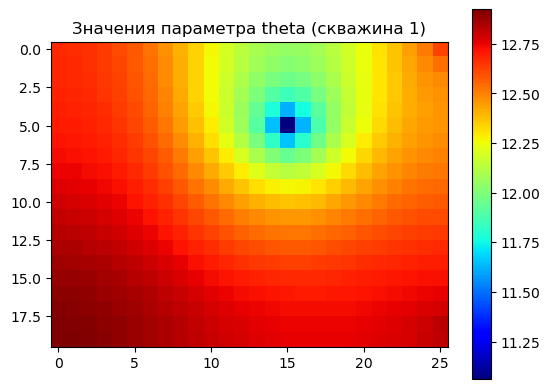


--- Обработка скважины 2 ---


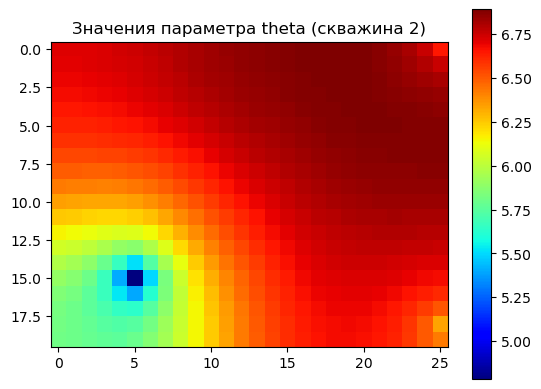

In [149]:
# Создаем правую часть системы (общая для всех скважин)
b = ct * dx_1 * dx_1 * Hef * por * a
B = b.reshape(-1, 1)

# Словарь для результатов
results = {}

# Цикл по всем скважинам
for idx, (well_cell_idx, well_prod_idx) in enumerate(zip(well_positions, well_prod_indexes), 1):
    print(f"\n--- Обработка скважины {idx} ---")
    
    # Решаем систему
    A = build_system_matrix(N, M, perm, Hef, cDarcy, well_cell_idx, well_prod_idx)
    x = solve(A, B)
    
    # Преобразуем решение
    theta = np.reshape(x, (N+1, M+1))
    results[f'theta_{idx}'] = theta
    
    display_grid(theta, f'Значения параметра theta (скважина {idx})')

In [150]:
def dilate_mask(mask, N, M, radius=5):
    """Создает расширенную маску вокруг принятых ячеек"""
    dilated = np.zeros_like(mask)
    for i in range(N+1):
        for j in range(M+1):
            if mask[i,j] > 0:
                # Создаем окно вокруг текущей ячейки
                i_start = max(0, i-radius)
                i_end = min(N+1, i+radius+1)
                j_start = max(0, j-radius)
                j_end = min(M+1, j+radius+1)
                
                # Проверяем условие |k| + |s| < radius+1 для каждой ячейки в окне
                for k in range(i_start, i_end):
                    for s in range(j_start, j_end):
                        if abs(k-i) + abs(s-j) < radius+1:
                            dilated[k,s] = 1
    return dilated

def calculate_threshold(theta_discret, theta_accepted, theta_dilation, Heff, poros, dx_1):
    """Вычисляет пороговое значение для текущего шага"""
    # Создаем маску для необработанных ячеек в области дилатации
    mask = (theta_dilation == 1) & (theta_accepted == 0)
    
    # Вычисляем числитель и знаменатель порогового значения
    numerator = np.sum(theta_discret[mask] * Heff[mask] * poros[mask] * dx_1**2)
    denominator = np.sum(Heff[mask] * poros[mask] * dx_1**2)
    
    return numerator / denominator if denominator > 0 else 0

def process_step(theta_discret, theta_accepted, theta_dilation, threshold, Heff, poros, dx_1):
    """Обрабатывает один шаг алгоритма"""
    # Обновляем значения для ячеек, которые меньше порога
    mask = (theta_dilation == 1) & (theta_accepted == 0) & (theta_discret < threshold)
    theta_discret[mask] = threshold
    theta_accepted[mask] = 1
    
    return theta_discret, theta_accepted

def main_algorithm(theta, Heff, poros, dx_1, N, M, well_i, well_j, tolerance = 0.005):
    """Основная функция алгоритма"""
    # Инициализация
    step = 0

    theta_discret = theta.copy()
    theta_accepted = np.zeros((N+1, M+1))
    theta_accepted[well_i, well_j] = 1

    while True:
        # Создаем расширенную маску
        theta_dilation = dilate_mask(theta_accepted, N, M)
        
        # Вычисляем пороговое значение
        threshold = calculate_threshold(theta_discret, theta_accepted, theta_dilation, Heff, poros, dx_1)
        
        # Обрабатываем текущий шаг
        theta_discret, theta_accepted = process_step(theta_discret, theta_accepted, theta_dilation, threshold, Heff, poros, dx_1)
        
        step += 1
        accepted_ratio = np.mean(theta_accepted == 1)
        print(f"Step {step}, threshold: {threshold:.6f}, accepted cells: {accepted_ratio*100:.2f}%")
        
        # Проверяем условие остановки
        if accepted_ratio >= (1.0 - tolerance):
            print(f"\n Algorithm converged after {step} steps")
            print(f"Final acceptance ratio: {accepted_ratio*100:.2f}%")
            last_mask = (theta_accepted == 0)
            theta_discret[last_mask] = threshold
            break
    
    return theta_discret, theta_accepted, step

In [151]:
theta_discret_1, theta_accepted_1, total_steps_1 = main_algorithm(
    theta=results['theta_1'],
    Heff=Heff,
    poros=poros,
    dx_1=dx_1,
    N=N,
    M=M,
    well_i=Well_1[0],
    well_j=Well_1[1]
)


theta_discret_2, theta_accepted_2, total_steps_2 = main_algorithm(
    theta=results['theta_2'],
    Heff=Heff,
    poros=poros,
    dx_1=dx_1,
    N=N,
    M=M,
    well_i=Well_2[0],
    well_j=Well_2[1]
)

Step 1, threshold: 12.030822, accepted cells: 5.19%
Step 2, threshold: 12.257593, accepted cells: 15.38%
Step 3, threshold: 12.424586, accepted cells: 27.69%
Step 4, threshold: 12.554381, accepted cells: 41.73%
Step 5, threshold: 12.651526, accepted cells: 54.81%
Step 6, threshold: 12.717513, accepted cells: 69.23%
Step 7, threshold: 12.765874, accepted cells: 81.54%
Step 8, threshold: 12.809149, accepted cells: 88.46%
Step 9, threshold: 12.849389, accepted cells: 92.88%
Step 10, threshold: 12.879785, accepted cells: 95.96%
Step 11, threshold: 12.901006, accepted cells: 97.88%
Step 12, threshold: 12.912097, accepted cells: 98.85%
Step 13, threshold: 12.917840, accepted cells: 99.42%
Step 14, threshold: 12.921397, accepted cells: 99.81%

 Algorithm converged after 14 steps
Final acceptance ratio: 99.81%
Step 1, threshold: 5.894497, accepted cells: 6.35%
Step 2, threshold: 6.174666, accepted cells: 14.04%
Step 3, threshold: 6.418696, accepted cells: 21.54%
Step 4, threshold: 6.574146, ac

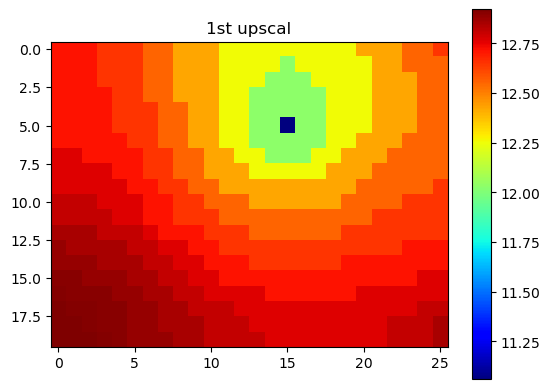

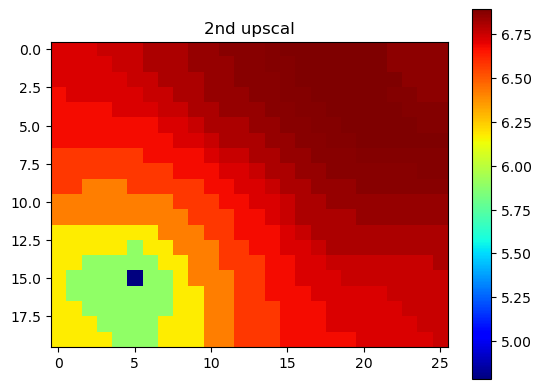

In [152]:
display_grid(theta_discret_1,'1st upscal')
display_grid(theta_discret_2,'2nd upscal')

In [153]:
def check_isol_cells(map):

    theta_discret = map

    for i in range(theta_discret.shape[0]):
        for j in range(theta_discret.shape[1]):     
            coeffs = np.zeros(4)
            two_d = (i,j)   
            # LEFT
            if i > 0:
                left_idx = (i-1, j)
                if theta_discret[left_idx] == theta_discret[two_d]:
                    coeffs[0] +=1

            # RIGHT
            if i < np.shape(poros)[0]-1:
                right_idx = (i+1, j)
                if theta_discret[right_idx] == theta_discret[two_d]:
                    coeffs[1] +=1 
            
            # TOP
            if j > 0:
                top_idx = (i, j-1)
                if theta_discret[top_idx] == theta_discret[two_d]:
                    coeffs[2] += 1
                    
            # BOT
            if j < np.shape(poros)[1]-1:
                bot_idx = (i, j+1)
                if theta_discret[bot_idx] == theta_discret[two_d]:
                    coeffs[3] += 1 

            if [i,j] == Well_1 or [i,j] == Well_2:
                coeffs[0] = 10
            if np.sum(coeffs) == 0:
                if i>0:
                    theta_discret[two_d] = theta_discret[left_idx]
                elif j>0: 
                    theta_discret[two_d] = theta_discret[top_idx]
                elif j<np.shape(poros)[1]:
                    theta_discret[two_d] = theta_discret[bot_idx]
    return theta_discret

            

In [154]:
theta_discret_2 = check_isol_cells(theta_discret_2)
theta_discret_1 = check_isol_cells(theta_discret_1)


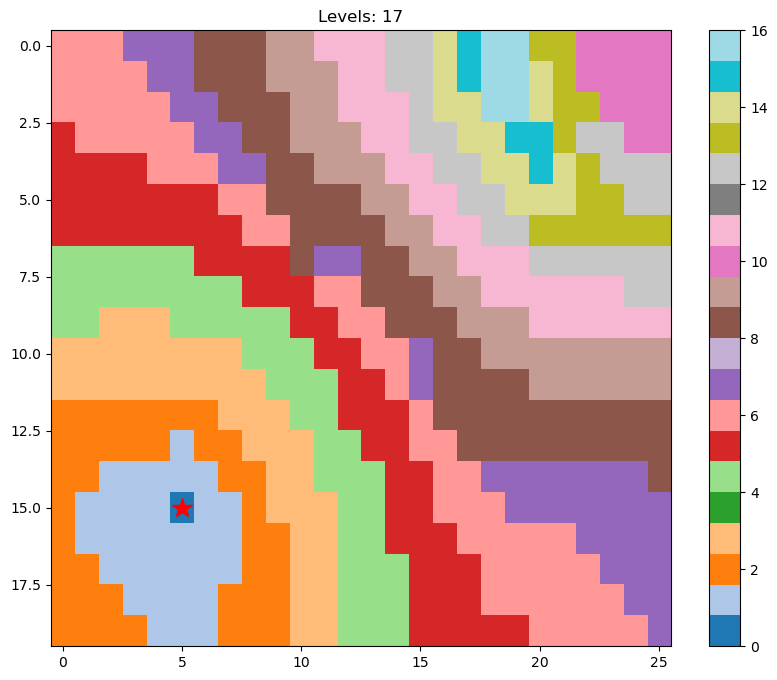

In [155]:
theta_discret = theta_discret_2
well_i = Well_2[0]
well_j = Well_2[1]

unique_levels = np.unique(theta_discret)
level_map = np.zeros_like(theta_discret, dtype=int)
for idx, level in enumerate(unique_levels):
    level_map[theta_discret == level] = idx

plt.figure(figsize=(10, 8))
plt.imshow(level_map, cmap='tab20', aspect='auto', interpolation='none')
plt.plot(well_j, well_i, 'r*', markersize=15)
plt.colorbar()
plt.title(f'Levels: {len(unique_levels)}')
plt.show()

# в вычислении $T^+$ и $T^-$ нужно исправить ошибки, лучше откатиться к предыдущей версии, которая костыльно мной реализована, и ещё найти, какое я присвоила значение presure_new[I_Well, J_Well]

## старый варик

In [156]:
def build_mesh_and_pairs(theta_discret):
    """Группируем ячейки пласта по PSS-интервалам"""
    """Создание mesh и pairs_list"""
    valid_mask = ~np.isnan(theta_discret)
    mesh = np.unique(theta_discret[valid_mask])
    mesh.sort()
    theta_mesh = np.array(mesh)
    
    mask_interval = np.zeros((N+1, M+1, len(theta_mesh)))
    for i in range(len(theta_mesh)):
        mask_interval[..., i] = theta_discret == theta_mesh[i]
    
    pairs_list = []
    for k in range(len(theta_mesh)):
        interval_indxs_2D = np.where(mask_interval[..., k] == 1)
        pairs_list_unique = list(zip(interval_indxs_2D[0], interval_indxs_2D[1]))
        pairs_list.append(pairs_list_unique)
    
    return theta_mesh, pairs_list

def solve_interval_system(pairs, theta_discret, Heff, perm, poros, dx_1, direction='minus'):
    """Решение системы для одного интервала T+/-"""
    size_system = len(pairs)
    Matrix = np.zeros((size_system, size_system))
    
    for indx in range(size_system):
        two_d = pairs[indx]
        i, j = two_d
        coeffs = np.zeros(4)
        
        # LEFT
        if i > 0:
            left_idx = (i-1, j)
            if theta_discret[left_idx] == theta_discret[two_d]:
                coeffs[0] = cDarcy * (Heff[left_idx] + Heff[two_d]) / ((1/perm[left_idx]) + (1/perm[two_d]))
                l_column = pairs.index(left_idx)
                Matrix[indx][l_column] = -coeffs[0]
            elif (direction == 'plus' and theta_discret[left_idx] > theta_discret[two_d]) or \
                 (direction == 'minus' and theta_discret[left_idx] < theta_discret[two_d]):
                coeffs[0] = 2 * cDarcy * (Heff[left_idx] + Heff[two_d]) / ((1/perm[left_idx]) + (1/perm[two_d]))
        elif i == 0:
            coeffs[0] = 2 * cDarcy * (Heff[two_d] + Heff[two_d]) / ((1/perm[two_d]) + (1/perm[two_d]))
        
        # RIGHT
        if i < np.shape(poros)[0]-1:
            right_idx = (i+1, j)
            if theta_discret[right_idx] == theta_discret[two_d]:
                coeffs[1] = cDarcy * (Heff[right_idx] + Heff[two_d]) / ((1/perm[right_idx]) + (1/perm[two_d]))
                l_column = pairs.index(right_idx)
                Matrix[indx][l_column] = -coeffs[1]
            elif (direction == 'plus' and theta_discret[right_idx] > theta_discret[two_d]) or \
                 (direction == 'minus' and theta_discret[right_idx] < theta_discret[two_d]):
                coeffs[1] = 2 * cDarcy * (Heff[right_idx] + Heff[two_d]) / ((1/perm[right_idx]) + (1/perm[two_d]))
        elif i == np.shape(poros)[0]-1:
            coeffs[1] = 2 * cDarcy * (Heff[two_d] + Heff[two_d]) / ((1/perm[two_d]) + (1/perm[two_d]))
        
        # TOP
        if j > 0:
            top_idx = (i, j-1)
            if theta_discret[top_idx] == theta_discret[two_d]:
                coeffs[2] = cDarcy * (Heff[top_idx] + Heff[two_d]) / ((1/perm[top_idx]) + (1/perm[two_d]))
                l_column = pairs.index(top_idx)
                Matrix[indx][l_column] = -coeffs[2]
            elif (direction == 'plus' and theta_discret[top_idx] > theta_discret[two_d]) or \
                 (direction == 'minus' and theta_discret[top_idx] < theta_discret[two_d]):
                coeffs[2] = 2 * cDarcy * (Heff[top_idx] + Heff[two_d]) / ((1/perm[top_idx]) + (1/perm[two_d]))
        elif j == 0:
            coeffs[2] = 2 * cDarcy * (Heff[two_d] + Heff[two_d]) / ((1/perm[two_d]) + (1/perm[two_d]))
        
        # BOT
        if j < np.shape(poros)[1]-1:
            bot_idx = (i, j+1)
            if theta_discret[bot_idx] == theta_discret[two_d]:
                coeffs[3] = cDarcy * (Heff[bot_idx] + Heff[two_d]) / ((1/perm[bot_idx]) + (1/perm[two_d]))
                l_column = pairs.index(bot_idx)
                Matrix[indx][l_column] = -coeffs[3]
            elif (direction == 'plus' and theta_discret[bot_idx] > theta_discret[two_d]) or \
                 (direction == 'minus' and theta_discret[bot_idx] < theta_discret[two_d]):
                coeffs[3] = 2 * cDarcy * (Heff[bot_idx] + Heff[two_d]) / ((1/perm[bot_idx]) + (1/perm[two_d]))
        elif j == np.shape(poros)[1]-1:
            coeffs[3] = 2 * cDarcy * (Heff[two_d] + Heff[two_d]) / ((1/perm[two_d]) + (1/perm[two_d]))
        
        Matrix[indx][indx] = np.sum(coeffs)
        
        if np.sum(coeffs) == 0:
            print(f"Нулевая строка: {indx}, {two_d}")
            print(f"направление {direction}")
    b = np.array([Heff[two_d] * poros[two_d] * dx_1 * dx_1 for two_d in pairs])
    x = solve(Matrix, b)
    return x

def compute_flux_and_delta(pairs_list, theta_mesh, theta_discret, Heff, perm, poros, dx_1, pressure_field, direction='minus'):
    """Вычисление q_f и Delta_PSS"""
    q_f = np.zeros(len(theta_mesh))
    numerator = np.zeros(len(theta_mesh))
    denominator = np.zeros(len(theta_mesh))
    
    for interval_number in range(len(theta_mesh)):
        pairs = pairs_list[interval_number]
        for two_d in pairs:
            i, j = two_d
            coeffs = np.zeros(4)
            
            # LEFT
            if i > 0:
                left_idx = (i-1, j)
                cond = (direction == 'plus' and theta_discret[left_idx] > theta_discret[two_d]) or \
                       (direction == 'minus' and theta_discret[left_idx] < theta_discret[two_d])
                if cond:
                    coeffs[0] = cDarcy * (Heff[left_idx] + Heff[two_d]) / ((1/perm[left_idx]) + (1/perm[two_d]))
            elif i == 0:
                coeffs[0] = cDarcy * Heff[two_d] * perm[two_d]
            
            # RIGHT
            if i < np.shape(poros)[0]-1:
                right_idx = (i+1, j)
                cond = (direction == 'plus' and theta_discret[right_idx] > theta_discret[two_d]) or \
                       (direction == 'minus' and theta_discret[right_idx] < theta_discret[two_d])
                if cond:
                    coeffs[1] = cDarcy * (Heff[right_idx] + Heff[two_d]) / ((1/perm[right_idx]) + (1/perm[two_d]))
            elif i == np.shape(poros)[0]-1:
                coeffs[1] = cDarcy * Heff[two_d] * perm[two_d]
            
            # TOP
            if j > 0:
                top_idx = (i, j-1)
                cond = (direction == 'plus' and theta_discret[top_idx] > theta_discret[two_d]) or \
                       (direction == 'minus' and theta_discret[top_idx] < theta_discret[two_d])
                if cond:
                    coeffs[2] = cDarcy * (Heff[top_idx] + Heff[two_d]) / ((1/perm[top_idx]) + (1/perm[two_d]))
            elif j == 0:
                coeffs[2] = cDarcy * Heff[two_d] * perm[two_d]
            
            # BOT
            if j < np.shape(poros)[1]-1:
                bot_idx = (i, j+1)
                cond = (direction == 'plus' and theta_discret[bot_idx] > theta_discret[two_d]) or \
                       (direction == 'minus' and theta_discret[bot_idx] < theta_discret[two_d])
                if cond:
                    coeffs[3] = cDarcy * (Heff[bot_idx] + Heff[two_d]) / ((1/perm[bot_idx]) + (1/perm[two_d]))
            elif j == np.shape(poros)[1]-1:
                coeffs[3] = cDarcy * Heff[two_d] * perm[two_d]
            
            T_sum = np.sum(coeffs)
            q_f[interval_number] += Heff[two_d] * poros[two_d] * dx_1 * dx_1
            numerator[interval_number] += T_sum * pressure_field[two_d]
            denominator[interval_number] += T_sum
        
        if denominator[interval_number] > 0:
            Delta_PSS = numerator / denominator
        else:
            Delta_PSS = np.zeros_like(numerator)
    
    return q_f, Delta_PSS
'''
# === ОСНОВНОЙ ЦИКЛ ===
theta_discrets = [theta_discret_1, theta_discret_2]
T_plus_results = {}
T_minus_results = {}

perm = perm.reshape(Heff.shape)

for case_num, theta_discret in enumerate(theta_discrets, 1):
    print(f"\n--- Обработка случая {case_num} ---")
    
    theta_mesh, pairs_list = build_mesh_and_pairs(theta_discret)
    print(f"Интервалов: {len(theta_mesh)}")
    print(theta_mesh)
    
    # T- расчет
    pressure_new_minus = np.zeros_like(poros)
    for interval_number in range(len(theta_mesh)):
        x = solve_interval_system(pairs_list[interval_number], theta_discret, Heff, perm, poros, dx_1, 'minus')
        for idx, two_d in enumerate(pairs_list[interval_number]):
            pressure_new_minus[two_d] = x[idx]
    
    q_f, Delta_PSS_minus = compute_flux_and_delta(pairs_list, theta_mesh, theta_discret, Heff, perm, poros, dx_1, pressure_new_minus, 'minus')
    T_minus = q_f / Delta_PSS_minus
    
    # T+ расчет  
    pressure_new_plus = np.zeros_like(poros)
    for interval_number in range(len(theta_mesh)):
        x = solve_interval_system(pairs_list[interval_number], theta_discret, Heff, perm, poros, dx_1, 'plus')
        for idx, two_d in enumerate(pairs_list[interval_number]):
            pressure_new_plus[two_d] = x[idx]
    
    _, Delta_PSS_plus = compute_flux_and_delta(pairs_list, theta_mesh, theta_discret, Heff, perm, poros, dx_1, pressure_new_plus, 'plus')
    Delta_PSS_plus[0] = Delta_PSS_minus[0]  # Граничное условие
    T_plus = q_f / Delta_PSS_plus
    
    # Сохранение
    T_plus_results[f'case_{case_num}'] = T_plus
    T_minus_results[f'case_{case_num}'] = T_minus
    
    print(f"T_plus: {T_plus}")
    print(f"T_minus: {T_minus}")
'''

'\n# === ОСНОВНОЙ ЦИКЛ ===\ntheta_discrets = [theta_discret_1, theta_discret_2]\nT_plus_results = {}\nT_minus_results = {}\n\nperm = perm.reshape(Heff.shape)\n\nfor case_num, theta_discret in enumerate(theta_discrets, 1):\n    print(f"\n--- Обработка случая {case_num} ---")\n    \n    theta_mesh, pairs_list = build_mesh_and_pairs(theta_discret)\n    print(f"Интервалов: {len(theta_mesh)}")\n    print(theta_mesh)\n    \n    # T- расчет\n    pressure_new_minus = np.zeros_like(poros)\n    for interval_number in range(len(theta_mesh)):\n        x = solve_interval_system(pairs_list[interval_number], theta_discret, Heff, perm, poros, dx_1, \'minus\')\n        for idx, two_d in enumerate(pairs_list[interval_number]):\n            pressure_new_minus[two_d] = x[idx]\n    \n    q_f, Delta_PSS_minus = compute_flux_and_delta(pairs_list, theta_mesh, theta_discret, Heff, perm, poros, dx_1, pressure_new_minus, \'minus\')\n    T_minus = q_f / Delta_PSS_minus\n    \n    # T+ расчет  \n    pressure_new_p

## костыльный начал

### Минус для первой

In [157]:
heff_noNaN = Heff
perm_noNaN = permx
pressure_masked = np.zeros_like(poros)
pressure_masked.fill(np.nan)


In [158]:
I_well, J_well = Well_1[0], Well_1[1]
Well_Index = Well_Index_1
theta_mesh_1, pairs_list_1 = build_mesh_and_pairs(theta_discret_1)
theta_discret = theta_discret_1
theta_mesh, pairs_list = theta_mesh_1, pairs_list_1

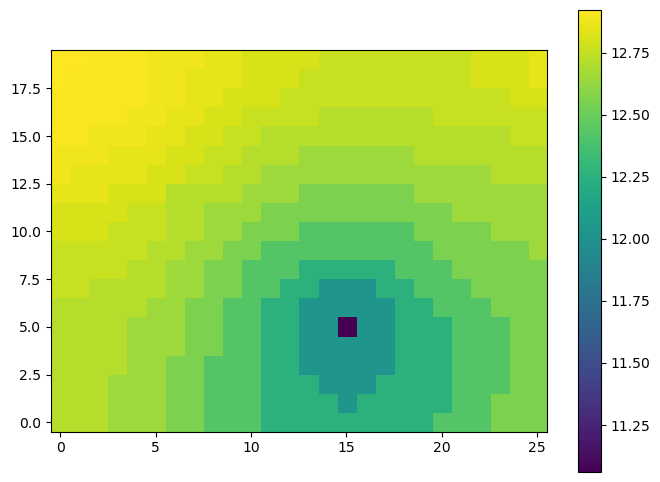

In [159]:
plt.figure(figsize=(8,6))
plt.imshow(
    theta_discret_1,
    origin='lower'
)
plt.colorbar()
plt.show()

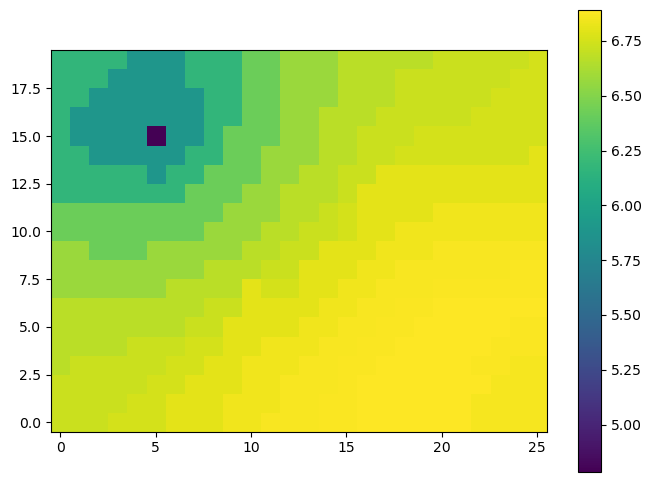

In [160]:
plt.figure(figsize=(8,6))
plt.imshow(
    theta_discret_2,
    origin='lower'
)
plt.colorbar()
plt.show()

In [161]:
pressure_new = np.zeros_like(poros)
for interval_number in range(1, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    Matrix = np.zeros((size_system, size_system))
    pairs = pairs_list[interval_number]
    for indx in range(size_system):
        two_d = pairs[indx]
        i, j = two_d
        coeffs = np.zeros(4)
        if i>0:
            left_idx = (i-1, j)
            if theta_discret[left_idx] == theta_discret[two_d]:
                coeffs[0] = cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(left_idx)
                Matrix[indx][l_column] = - coeffs[0]
            elif theta_discret[left_idx] < theta_discret[two_d]:
                coeffs[0] = 2 * cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
        if i<np.shape(poros)[0]-1:
            right_idx = (i+1, j)
            if theta_discret[right_idx] == theta_discret[two_d]:
                coeffs[1] = cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(right_idx)
                Matrix[indx][l_column] = - coeffs[1]
            elif theta_discret[right_idx] < theta_discret[two_d]:
                coeffs[1] = 2 * cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
        if j>0:
            top_idx = (i, j-1)
            if theta_discret[top_idx] == theta_discret[two_d]:
                coeffs[2] = cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(top_idx)
                Matrix[indx][l_column] = - coeffs[2]
            elif theta_discret[top_idx] < theta_discret[two_d]:
                coeffs[2] = 2 * cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
        if j<np.shape(poros)[1]-1:
            bot_idx = (i, j+1)
            if theta_discret[bot_idx] == theta_discret[two_d]:
                coeffs[3] = cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(bot_idx)
                Matrix[indx][l_column] = - coeffs[3]
            elif theta_discret[bot_idx] < theta_discret[two_d]:
                coeffs[3] = 2 * cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
        Matrix[indx][indx] = np.sum(coeffs)
        if np.sum(coeffs) == 0:
            print(indx, two_d, left_idx, right_idx, top_idx, bot_idx)
            print('Эфф. толщина в ячейках с нулевой строкой')
            print(Heff[two_d], Heff[left_idx], Heff[right_idx], Heff[top_idx], Heff[left_idx])
            print('Проницаемость в ячейках с нулевой строкой')
            print(permx[two_d], permx[left_idx], permx[right_idx], permx[top_idx], permx[left_idx])
    b = np.zeros(size_system)
    for indx in range(size_system):
        two_d = pairs[indx]
        b[indx] = Heff[two_d] * poros[two_d] * dx_1 * dx_1 

    x = solve(Matrix, b)
    #print(np.mean(x))
    
    for indx in range(size_system):
        two_d = pairs[indx]
        pressure_new[two_d] = x[indx]
    #display_grid(pressure_new, 'давления на шаге ' + str(interval_number))
        if interval_number == 2:
            pressure_masked[two_d] = x[indx]
pressure_new[I_well][J_well] = Heff[I_well][J_well] * poros[I_well][J_well] * dx_1 * dx_1 / Well_Index

In [162]:
q_f = np.zeros(len(theta_mesh))
for interval_number in range(0, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    pairs = pairs_list[interval_number]
    for indx in range(size_system):
        two_d = pairs[indx]
        #i, j = two_d
        q_f[interval_number] += Heff[two_d] * poros[two_d] * dx_1 * dx_1 

In [163]:
numerator = np.zeros(len(theta_mesh)) # числитель дроби
denominator = np.zeros_like(numerator) # знаменатель дроби
Delta_PSS = np.zeros_like(numerator)

for interval_number in range(0, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    pairs = pairs_list[interval_number]

    for indx in range(size_system):
        two_d = pairs[indx]
        i, j = two_d
        coeffs = np.zeros(4)
        if i>0:
            left_idx = (i-1, j)
            if theta_discret[left_idx] > theta_discret[two_d]:
                coeffs[0] = cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
        elif i == 0:
            coeffs[0] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]
            

        if i<np.shape(poros)[0]-1:
            right_idx = (i+1, j)
            if theta_discret[right_idx] > theta_discret[two_d]:
                coeffs[1] = cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
        elif i == np.shape(poros)[0]-1:
            coeffs[1] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]

        if j>0:
            top_idx = (i, j-1)
            if theta_discret[top_idx] > theta_discret[two_d]:
                coeffs[2] = cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
        elif j == 0:
            coeffs[2] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]


        if j<np.shape(poros)[1]-1:
            bot_idx = (i, j+1)
            if theta_discret[bot_idx] > theta_discret[two_d]:
                coeffs[3] = cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
        elif j == np.shape(poros)[1]-1:
            coeffs[3] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]

        T_sum = 0
        T_sum = np.sum(coeffs)
        numerator[interval_number] += T_sum * pressure_new[two_d]
        denominator[interval_number] += T_sum
        
    Delta_PSS[interval_number] = numerator[interval_number] / denominator[interval_number]

print(Delta_PSS)

[18087.55884321 25633.02013251 12087.97962657 12930.67887423
 11778.52272056 11320.7544119  12603.13178856 11872.0964928
  6450.26096105  6004.74754764  6422.44917397 10403.42298756
  5515.12588552  3984.59247398]


In [164]:
T_minus_1 = q_f / Delta_PSS
q_f_1 = q_f
T_minus_1

array([  0.98709285,  18.10350078,  78.11745463,  87.62629642,
       110.20609552, 102.69733427, 103.74264286,  88.45805799,
        90.9253445 ,  61.64650505,  39.83790188,  18.16616514,
        17.01924887,  11.81370499])

### Плюс для первой

In [165]:
pressure_masked_plus = np.zeros_like(poros)
pressure_masked_plus.fill(np.nan)

In [166]:
pressure_new_plus = np.zeros_like(poros)
pressure_new_plus.fill(np.nan)

for interval_number in range(0, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    Matrix = np.zeros((size_system, size_system))
    pairs = pairs_list[interval_number]
    for indx in range(size_system):
        two_d = pairs[indx]
        i, j = two_d
        coeffs = np.zeros(4)
        if i>0:
            left_idx = (i-1, j)
            if theta_discret[left_idx] == theta_discret[two_d]:
                coeffs[0] = cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(left_idx)
                Matrix[indx][l_column] = - coeffs[0]
            elif theta_discret[left_idx] > theta_discret[two_d]:
                coeffs[0] = 2 * cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
        elif i == 0:
            coeffs[0] = 2 * cDarcy * (heff_noNaN[two_d] + heff_noNaN[two_d]) / ((1/perm_noNaN[two_d]) + (1/perm_noNaN[two_d]))

        if i<np.shape(poros)[0]-1:
            right_idx = (i+1, j)
            if theta_discret[right_idx] == theta_discret[two_d]:
                coeffs[1] = cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(right_idx)
                Matrix[indx][l_column] = - coeffs[1]
            elif theta_discret[right_idx] > theta_discret[two_d]:
                coeffs[1] = 2 * cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
        
        elif i == np.shape(poros)[0]-1:
            coeffs[1] = 2 * cDarcy * (heff_noNaN[two_d] + heff_noNaN[two_d]) / ((1/perm_noNaN[two_d]) + (1/perm_noNaN[two_d]))
        
        
        if j>0:
            top_idx = (i, j-1)
            if theta_discret[top_idx] == theta_discret[two_d]:
                coeffs[2] = cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(top_idx)
                Matrix[indx][l_column] = - coeffs[2]
            elif theta_discret[top_idx] > theta_discret[two_d]:
                coeffs[2] = 2 * cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
        elif j == 0:
           coeffs[2] = 2 * cDarcy * (heff_noNaN[two_d] + heff_noNaN[two_d]) / ((1/perm_noNaN[two_d]) + (1/perm_noNaN[two_d])) 
        
        if j<np.shape(poros)[1]-1:
            bot_idx = (i, j+1)
            if theta_discret[bot_idx] == theta_discret[two_d]:
                coeffs[3] = cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(bot_idx)
                Matrix[indx][l_column] = - coeffs[3]
            elif theta_discret[bot_idx] > theta_discret[two_d]:
                coeffs[3] = 2 * cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
        elif j == np.shape(poros)[1]-1:
            coeffs[3] = 2 * cDarcy * (heff_noNaN[two_d] + heff_noNaN[two_d]) / ((1/perm_noNaN[two_d]) + (1/perm_noNaN[two_d]))



        Matrix[indx][indx] = np.sum(coeffs)
        if np.sum(coeffs) == 0:
            print(indx, two_d, left_idx, right_idx, top_idx, bot_idx)
            print('Эфф. толщина в ячейках с нулевой строкой')
            print(Heff[two_d], Heff[left_idx], Heff[right_idx], Heff[top_idx], Heff[left_idx])
            print('Проницаемость в ячейках с нулевой строкой')
            print(permx[two_d], permx[left_idx], permx[right_idx], permx[top_idx], permx[left_idx])
    b = np.zeros(size_system)
    for indx in range(size_system):
        two_d = pairs[indx]
        b[indx] = Heff[two_d] * poros[two_d] * dx_1 * dx_1 

    x = solve(Matrix, b)
    #print(np.mean(x))
    
    for indx in range(size_system):
        two_d = pairs[indx]
        pressure_new_plus[two_d] = x[indx]
        
        if interval_number == 2:
            pressure_masked_plus[two_d] = x[indx]

In [167]:
numerator = np.zeros(len(theta_mesh)) # числитель дроби
denominator = np.zeros_like(numerator) # знаменатель дроби
Delta_PSS_plus = np.zeros_like(numerator)

for interval_number in range(1, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    pairs = pairs_list[interval_number]

    for indx in range(size_system):
        two_d = pairs[indx]
        i, j = two_d
        coeffs = np.zeros(4)
        if i>0:
            left_idx = (i-1, j)
            if theta_discret[left_idx] < theta_discret[two_d]:
                coeffs[0] = cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
        elif i == 0:
            coeffs[0] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]
            

        if i<np.shape(poros)[0]-1:
            right_idx = (i+1, j)
            if theta_discret[right_idx] < theta_discret[two_d]:
                coeffs[1] = cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
        elif i == np.shape(poros)[0]-1:
            coeffs[1] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]

        if j>0:
            top_idx = (i, j-1)
            if theta_discret[top_idx] < theta_discret[two_d]:
                coeffs[2] = cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
        elif j == 0:
            coeffs[2] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]


        if j<np.shape(poros)[1]-1:
            bot_idx = (i, j+1)
            if theta_discret[bot_idx] < theta_discret[two_d]:
                coeffs[3] = cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
        elif j == np.shape(poros)[1]-1:
            coeffs[3] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]

        T_sum = 0
        T_sum = np.sum(coeffs)
        numerator[interval_number] += T_sum * pressure_new[two_d]
        denominator[interval_number] += T_sum
        
    Delta_PSS_plus[interval_number] = numerator[interval_number] / denominator[interval_number]

print(Delta_PSS_plus)

[    0.         12230.63164966  6498.81592348  5706.58367245
  6850.72396462  5496.88901491  7775.27271402  7263.84282829
  3703.773662    2985.82766046  3743.09049529  5521.09571001
  3003.23880367  3185.20641521]


In [168]:
Delta_PSS_plus[0] = Delta_PSS[0]
T_plus_1 = q_f / Delta_PSS_plus 
T_plus_1

array([  0.98709285,  37.94140918, 145.3006534 , 198.55443555,
       189.47851449, 211.50350623, 168.15901488, 144.57672403,
       158.34990297, 123.97624448,  68.35445211,  34.23057848,
        31.25402478,  14.77857126])

### Минус для второй

In [169]:
heff_noNaN = Heff
perm_noNaN = permx
pressure_masked = np.zeros_like(poros)
pressure_masked.fill(np.nan)


In [170]:
I_well, J_well = Well_2[0], Well_2[1]
Well_Index = Well_Index_2
theta_mesh_2, pairs_list_2 = build_mesh_and_pairs(theta_discret_2)
theta_discret = theta_discret_2
theta_mesh, pairs_list = theta_mesh_2, pairs_list_2

In [171]:
Matrix

array([[ 7.14416609, -2.40731134,  0.        ],
       [-2.40731134, 14.69848211, -2.50119723],
       [ 0.        , -2.50119723,  7.61581872]])

In [172]:
b

array([15672.5, 15708.1, 15692.2])

In [173]:
x = solve(Matrix, b)

In [174]:
pressure_new = np.zeros_like(poros)
for interval_number in range(1, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    Matrix = np.zeros((size_system, size_system))
    pairs = pairs_list[interval_number]
    for indx in range(size_system):
        two_d = pairs[indx]
        i, j = two_d
        coeffs = np.zeros(4)
        if i>0:
            left_idx = (i-1, j)
            if theta_discret[left_idx] == theta_discret[two_d]:
                coeffs[0] = cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(left_idx)
                Matrix[indx][l_column] = - coeffs[0]
            elif theta_discret[left_idx] < theta_discret[two_d]:
                coeffs[0] = 2 * cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
        if i<np.shape(poros)[0]-1:
            right_idx = (i+1, j)
            if theta_discret[right_idx] == theta_discret[two_d]:
                coeffs[1] = cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(right_idx)
                Matrix[indx][l_column] = - coeffs[1]
            elif theta_discret[right_idx] < theta_discret[two_d]:
                coeffs[1] = 2 * cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
        if j>0:
            top_idx = (i, j-1)
            if theta_discret[top_idx] == theta_discret[two_d]:
                coeffs[2] = cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(top_idx)
                Matrix[indx][l_column] = - coeffs[2]
            elif theta_discret[top_idx] < theta_discret[two_d]:
                coeffs[2] = 2 * cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
        if j<np.shape(poros)[1]-1:
            bot_idx = (i, j+1)
            if theta_discret[bot_idx] == theta_discret[two_d]:
                coeffs[3] = cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(bot_idx)
                Matrix[indx][l_column] = - coeffs[3]
            elif theta_discret[bot_idx] < theta_discret[two_d]:
                coeffs[3] = 2 * cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
        Matrix[indx][indx] = np.sum(coeffs)
        if np.sum(coeffs) == 0:
            print(indx, two_d, left_idx, right_idx, top_idx, bot_idx)
            print('Эфф. толщина в ячейках с нулевой строкой')
            print(Heff[two_d], Heff[left_idx], Heff[right_idx], Heff[top_idx], Heff[left_idx])
            print('Проницаемость в ячейках с нулевой строкой')
            print(permx[two_d], permx[left_idx], permx[right_idx], permx[top_idx], permx[left_idx])
    b = np.zeros(size_system)
    for indx in range(size_system):
        two_d = pairs[indx]
        b[indx] = Heff[two_d] * poros[two_d] * dx_1 * dx_1 

    #x = solve(Matrix, b)
    #x, residuals, rank, s = np.linalg.lstsq(Matrix, b, rcond=1e-15)

    # Сингулярное разложение
    U, S, Vt = np.linalg.svd(Matrix, full_matrices=False)

    # Отсечение малых сингулярных чисел
    threshold = 1e-12  # порог
    S_inv = np.zeros_like(S)
    S_inv[S > threshold] = 1 / S[S > threshold]

    # Псевдообратная матрица
    A_pinv = Vt.T @ np.diag(S_inv) @ U.T

    # Решение
    x = A_pinv @ b

    #print(np.mean(x))
    
    for indx in range(size_system):
        two_d = pairs[indx]
        pressure_new[two_d] = x[indx]
        #if interval_number == 11:
        #display_grid(pressure_new, 'давления на шаге ' + str(interval_number))
            #print(Matrix)
            #print(b)
            #print(x)
pressure_new[I_well][J_well] = Heff[I_well][J_well] * poros[I_well][J_well] * dx_1 * dx_1 / Well_Index

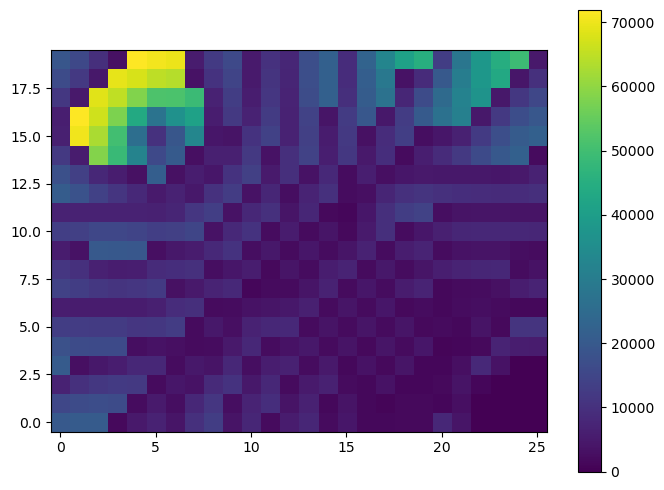

In [175]:
plt.figure(figsize=(8,6))
plt.imshow(
    pressure_new,
    origin='lower'
)
plt.colorbar()
plt.show()


In [176]:
q_f = np.zeros(len(theta_mesh))
for interval_number in range(0, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    pairs = pairs_list[interval_number]
    for indx in range(size_system):
        two_d = pairs[indx]
        #i, j = two_d
        q_f[interval_number] += Heff[two_d] * poros[two_d] * dx_1 * dx_1 

In [177]:
numerator = np.zeros(len(theta_mesh)) # числитель дроби
denominator = np.zeros_like(numerator) # знаменатель дроби
Delta_PSS = np.zeros_like(numerator)

for interval_number in range(0, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    pairs = pairs_list[interval_number]

    for indx in range(size_system):
        two_d = pairs[indx]
        i, j = two_d
        coeffs = np.zeros(4)
        if i>0:
            left_idx = (i-1, j)
            if theta_discret[left_idx] > theta_discret[two_d]:
                coeffs[0] = cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
        elif i == 0:
            coeffs[0] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]
            

        if i<np.shape(poros)[0]-1:
            right_idx = (i+1, j)
            if theta_discret[right_idx] > theta_discret[two_d]:
                coeffs[1] = cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
        elif i == np.shape(poros)[0]-1:
            coeffs[1] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]

        if j>0:
            top_idx = (i, j-1)
            if theta_discret[top_idx] > theta_discret[two_d]:
                coeffs[2] = cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
        elif j == 0:
            coeffs[2] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]


        if j<np.shape(poros)[1]-1:
            bot_idx = (i, j+1)
            if theta_discret[bot_idx] > theta_discret[two_d]:
                coeffs[3] = cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
        elif j == np.shape(poros)[1]-1:
            coeffs[3] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]

        T_sum = 0
        T_sum = np.sum(coeffs)
        numerator[interval_number] += T_sum * pressure_new[two_d]
        denominator[interval_number] += T_sum
        
    Delta_PSS[interval_number] = numerator[interval_number] / denominator[interval_number]

print(Delta_PSS)

[1.01063218e+04 5.19731618e+04 1.11603272e+04 1.38412588e+04
 1.25719679e+04 1.70039015e+04 1.65356239e+04 8.32079757e+03
 8.71033107e+03 6.10689897e+03 8.45551651e+00 5.43649551e+03
 4.97155816e+03 4.14279764e+03 2.50836721e+03 1.20139033e+03
 1.80629397e+03]


In [178]:
T_minus_2 = q_f / Delta_PSS
q_f_2 = q_f
T_minus_2

array([1.62457720e+00, 9.85663720e+00, 5.72235641e+01, 4.68933217e+01,
       6.35970681e+01, 5.67670249e+01, 6.29211455e+01, 8.07585924e+01,
       1.13216960e+02, 1.09590285e+02, 2.68037677e+04, 1.00859736e+02,
       9.88514032e+01, 6.34541493e+01, 9.84016612e+01, 7.35093314e+01,
       5.90077261e+01])

### Плюс для второй

In [179]:
pressure_masked_plus = np.zeros_like(poros)
pressure_masked_plus.fill(np.nan)

In [180]:
pressure_new_plus = np.zeros_like(poros)
pressure_new_plus.fill(np.nan)

for interval_number in range(0, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    Matrix = np.zeros((size_system, size_system))
    pairs = pairs_list[interval_number]
    for indx in range(size_system):
        two_d = pairs[indx]
        i, j = two_d
        coeffs = np.zeros(4)
        if i>0:
            left_idx = (i-1, j)
            if theta_discret[left_idx] == theta_discret[two_d]:
                coeffs[0] = cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(left_idx)
                Matrix[indx][l_column] = - coeffs[0]
            elif theta_discret[left_idx] > theta_discret[two_d]:
                coeffs[0] = 2 * cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
        elif i == 0:
            coeffs[0] = 2 * cDarcy * (heff_noNaN[two_d] + heff_noNaN[two_d]) / ((1/perm_noNaN[two_d]) + (1/perm_noNaN[two_d]))

        if i<np.shape(poros)[0]-1:
            right_idx = (i+1, j)
            if theta_discret[right_idx] == theta_discret[two_d]:
                coeffs[1] = cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(right_idx)
                Matrix[indx][l_column] = - coeffs[1]
            elif theta_discret[right_idx] > theta_discret[two_d]:
                coeffs[1] = 2 * cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
        
        elif i == np.shape(poros)[0]-1:
            coeffs[1] = 2 * cDarcy * (heff_noNaN[two_d] + heff_noNaN[two_d]) / ((1/perm_noNaN[two_d]) + (1/perm_noNaN[two_d]))
        
        
        if j>0:
            top_idx = (i, j-1)
            if theta_discret[top_idx] == theta_discret[two_d]:
                coeffs[2] = cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(top_idx)
                Matrix[indx][l_column] = - coeffs[2]
            elif theta_discret[top_idx] > theta_discret[two_d]:
                coeffs[2] = 2 * cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
        elif j == 0:
           coeffs[2] = 2 * cDarcy * (heff_noNaN[two_d] + heff_noNaN[two_d]) / ((1/perm_noNaN[two_d]) + (1/perm_noNaN[two_d])) 
        
        if j<np.shape(poros)[1]-1:
            bot_idx = (i, j+1)
            if theta_discret[bot_idx] == theta_discret[two_d]:
                coeffs[3] = cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
                l_column = pairs.index(bot_idx)
                Matrix[indx][l_column] = - coeffs[3]
            elif theta_discret[bot_idx] > theta_discret[two_d]:
                coeffs[3] = 2 * cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
        elif j == np.shape(poros)[1]-1:
            coeffs[3] = 2 * cDarcy * (heff_noNaN[two_d] + heff_noNaN[two_d]) / ((1/perm_noNaN[two_d]) + (1/perm_noNaN[two_d]))



        Matrix[indx][indx] = np.sum(coeffs)
        if np.sum(coeffs) == 0:
            print(indx, two_d, left_idx, right_idx, top_idx, bot_idx)
            print('Эфф. толщина в ячейках с нулевой строкой')
            print(Heff[two_d], Heff[left_idx], Heff[right_idx], Heff[top_idx], Heff[left_idx])
            print('Проницаемость в ячейках с нулевой строкой')
            print(permx[two_d], permx[left_idx], permx[right_idx], permx[top_idx], permx[left_idx])
    b = np.zeros(size_system)
    for indx in range(size_system):
        two_d = pairs[indx]
        b[indx] = Heff[two_d] * poros[two_d] * dx_1 * dx_1 

    #x = solve(Matrix, b)
    #x, residuals, rank, s = np.linalg.lstsq(Matrix, b, rcond=1e-15)
        # Сингулярное разложение
    U, S, Vt = np.linalg.svd(Matrix, full_matrices=False)

    # Отсечение малых сингулярных чисел
    threshold = 1e-12  # порог
    S_inv = np.zeros_like(S)
    S_inv[S > threshold] = 1 / S[S > threshold]

    # Псевдообратная матрица
    A_pinv = Vt.T @ np.diag(S_inv) @ U.T

    # Решение
    x = A_pinv @ b
    #print(np.mean(x))
    
    for indx in range(size_system):
        two_d = pairs[indx]
        pressure_new_plus[two_d] = x[indx]
        
        if interval_number == 2:
            pressure_masked_plus[two_d] = x[indx]

In [181]:
size_system = len(pairs_list[10])
pairs = pairs_list[10]
for indx in range(size_system):
    two_d = pairs[indx]
    i, j = two_d
    coeffs = np.zeros(4)
    if i>0:
        left_idx = (i-1, j)
        if theta_discret[left_idx] < theta_discret[two_d]:
            coeffs[0] = cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
    elif i == 0:
        coeffs[0] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]
        
    if i<np.shape(poros)[0]-1:
        right_idx = (i+1, j)
        if theta_discret[right_idx] < theta_discret[two_d]:
            coeffs[1] = cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
    elif i == np.shape(poros)[0]-1:
        coeffs[1] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]
    if j>0:
        top_idx = (i, j-1)
        if theta_discret[top_idx] < theta_discret[two_d]:
            coeffs[2] = cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
    elif j == 0:
        coeffs[2] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]
    if j<np.shape(poros)[1]-1:
        bot_idx = (i, j+1)
        if theta_discret[bot_idx] < theta_discret[two_d]:
            coeffs[3] = cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
    elif j == np.shape(poros)[1]-1:
        coeffs[3] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]
    T_sum = 0
    T_sum = np.sum(coeffs)
    numerator[10] += T_sum * pressure_new[two_d]
    denominator[10] += T_sum

In [182]:
pressure_new

array([[ 2.00790563e+04,  2.04658080e+04,  2.06800487e+04,
         1.71533347e+03,  4.80749949e+03,  6.86704876e+03,
         4.08013286e+03,  9.80048470e+03,  1.28917285e+04,
         3.73048797e+03,  7.54597816e+03,  1.93713327e+03,
         5.54750208e+03,  7.55642270e+03,  2.17673332e+03,
         4.31666580e+03,  1.44246445e+03,  1.36203655e+03,
         1.74643814e+03,  1.87037672e+03,  8.02774995e+03,
         3.89944917e+03,  9.34260658e+01,  4.22550817e+01,
        -2.09194164e+01, -6.15605205e+01],
       [ 1.53653922e+04,  1.64774144e+04,  1.70703912e+04,
         1.63215252e+04,  2.20456060e+03,  5.02494767e+03,
         2.68767647e+03,  8.03285345e+03,  1.14004076e+04,
         2.61942473e+03,  7.11909925e+03,  9.41219682e+03,
         3.61653458e+03,  6.54055816e+03,  1.49163910e+03,
         3.65645176e+03,  1.46808906e+03,  9.56245613e+02,
         1.64463426e+03,  1.74247984e+03,  1.18168020e+03,
         3.02765702e+03,  9.16567022e+01,  3.89855104e+01,
        -1.79

In [183]:
numerator = np.zeros(len(theta_mesh)) # числитель дроби
denominator = np.zeros_like(numerator) # знаменатель дроби
Delta_PSS_plus = np.zeros_like(numerator)

for interval_number in range(1, len(theta_mesh)):
    size_system = len(pairs_list[interval_number])
    pairs = pairs_list[interval_number]

    for indx in range(size_system):
        two_d = pairs[indx]
        i, j = two_d
        coeffs = np.zeros(4)
        if i>0:
            left_idx = (i-1, j)
            if theta_discret[left_idx] < theta_discret[two_d]:
                coeffs[0] = cDarcy * (heff_noNaN[left_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[left_idx]) + (1/perm_noNaN[two_d]))
        elif i == 0:
            coeffs[0] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]
            

        if i<np.shape(poros)[0]-1:
            right_idx = (i+1, j)
            if theta_discret[right_idx] < theta_discret[two_d]:
                coeffs[1] = cDarcy * (heff_noNaN[right_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[right_idx]) + (1/perm_noNaN[two_d]))
        elif i == np.shape(poros)[0]-1:
            coeffs[1] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]

        if j>0:
            top_idx = (i, j-1)
            if theta_discret[top_idx] < theta_discret[two_d]:
                coeffs[2] = cDarcy * (heff_noNaN[top_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[top_idx]) + (1/perm_noNaN[two_d]))
        elif j == 0:
            coeffs[2] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]


        if j<np.shape(poros)[1]-1:
            bot_idx = (i, j+1)
            if theta_discret[bot_idx] < theta_discret[two_d]:
                coeffs[3] = cDarcy * (heff_noNaN[bot_idx] + heff_noNaN[two_d]) / ((1/perm_noNaN[bot_idx]) + (1/perm_noNaN[two_d]))
        elif j == np.shape(poros)[1]-1:
            coeffs[3] = cDarcy * heff_noNaN[two_d] * perm_noNaN[two_d]

        T_sum = 0
        T_sum = np.sum(coeffs)
        numerator[interval_number] += T_sum * pressure_new[two_d]
        if interval_number == 10:
            print(pressure_new[two_d])
        denominator[interval_number] += T_sum
        
    Delta_PSS_plus[interval_number] = numerator[interval_number] / denominator[interval_number]

print(Delta_PSS_plus)

93.42606578168488
42.255081744221116
-20.919416350043093
-61.56052048259335
91.65670219025651
38.985510376076945
-17.986576732017284
-53.84992447873992
21.26271601045437
-18.421262920902052
-43.38603950430297
-29.937547148220347
-41.524788485875206
[ 0.00000000e+00  4.28241074e+04  7.44745263e+03  6.22930775e+03
  6.49325689e+03  9.54090265e+03  8.76146365e+03  4.52270084e+03
  3.98635772e+03  3.14473047e+03 -1.55932029e+01  2.79422888e+03
  2.80548733e+03  2.33969694e+03  1.58667479e+03  1.06532776e+03
  1.53534321e+03]


In [184]:
Delta_PSS_plus[0] = Delta_PSS[0]
T_plus_2 = q_f / Delta_PSS_plus 
T_plus_2

array([ 1.62457720e+00,  1.19624350e+01,  8.57519653e+01,  1.04194981e+02,
        1.23133939e+02,  1.01170815e+02,  1.18751894e+02,  1.48578454e+02,
        2.47383017e+02,  2.12818493e+02, -1.45345188e+04,  1.96234283e+02,
        1.75172953e+02,  1.12355449e+02,  1.55562754e+02,  8.28978682e+01,
        6.94211555e+01])

## костыльный всё

In [185]:
#T_plus_1, T_minus_1 = T_plus_results['case_1'], T_minus_results['case_1']
#T_plus_2, T_minus_2 = T_plus_results['case_2'], T_minus_results['case_2']

### костылей мало было мне, решила ещё добавить, чтобы починить 11-й интервал, где трансмиссибилити почему-то получилась отрицательным нулём

In [186]:
T_plus_fix  = T_plus_2.copy()
T_minus_fix = T_minus_2.copy()

for T in (T_plus_fix, T_minus_fix):
    bad = ~np.isfinite(T) | (T <= 0)
    for i in np.where(bad)[0]:
        if 0 < i < len(T)-1:
            T[i] = 0.5 * (T[i-1] + T[i+1])
        elif i == 0:
            T[i] = T[i+1]
        else:
            T[i] = T[i-1]

In [187]:
T_plus_2 = T_plus_fix
T_minus_2 = T_minus_fix

In [188]:
# Старая версия
def theta_to_tau_map(theta_discret, Vp, ct, T_plus, T_minus, lambda_rt0):
    theta_unique = np.sort(np.unique(theta_discret))
    print(f"PSS интервалы: {len(theta_unique)}")
    
    if len(theta_unique) < 2:
        raise ValueError("Нужно минимум 2 PSS интервала")
    
    # Δθ
    dtheta = np.diff(theta_unique)
    
    # Кумулятивный запас Cp
    ct = np.full_like(theta_discret, ct)
    
    Cp = np.zeros(len(theta_unique))
    for i, theta_val in enumerate(theta_unique):
        mask = (theta_discret == theta_val)
        Cp[i] = np.sum(Vp[mask] * ct[mask])
    
    tau_intervals = np.zeros(len(theta_unique))
    for i in range(1, len(theta_unique)):
        denom = 2 / (1/(T_plus[i-1] * lambda_rt0[i-1]) + 1/(T_minus[i-1] * lambda_rt0[i-1]))
        # пыталась найти уродов
        # print(f"number: {i}, корень:{np.sqrt(Cp[i-1] / denom)}")
        # print(f"denom: {denom}, Cp[i-1]: {Cp[i-1]}, dtheta[i-1]: {dtheta[i-1]}, tau_prev:{tau_intervals[i-1]}")
        # нашла и избавилась от них
        tau_intervals[i] = (tau_intervals[i-1] + 
                           np.sqrt(Cp[i-1] / denom) * dtheta[i-1])
    
    tau_map = np.interp(theta_discret.flatten(), theta_unique, tau_intervals)
    return tau_map.reshape(theta_discret.shape), theta_unique, tau_intervals

In [189]:
dtheta = np.diff(np.sort(np.unique(theta_discret_1)))
dtheta

array([0.96974566, 0.22677056, 0.16699333, 0.1297948 , 0.09714532,
       0.06598659, 0.04836175, 0.04327466, 0.04023993, 0.03039635,
       0.0212203 , 0.01109123, 0.00929981])

Здесь говориться, что обычно за граничное условие берется $\tau = 0$, но лучше сделать иначе (там что-то через сложную геометрию ячеек). Я брал $\tau=0$.

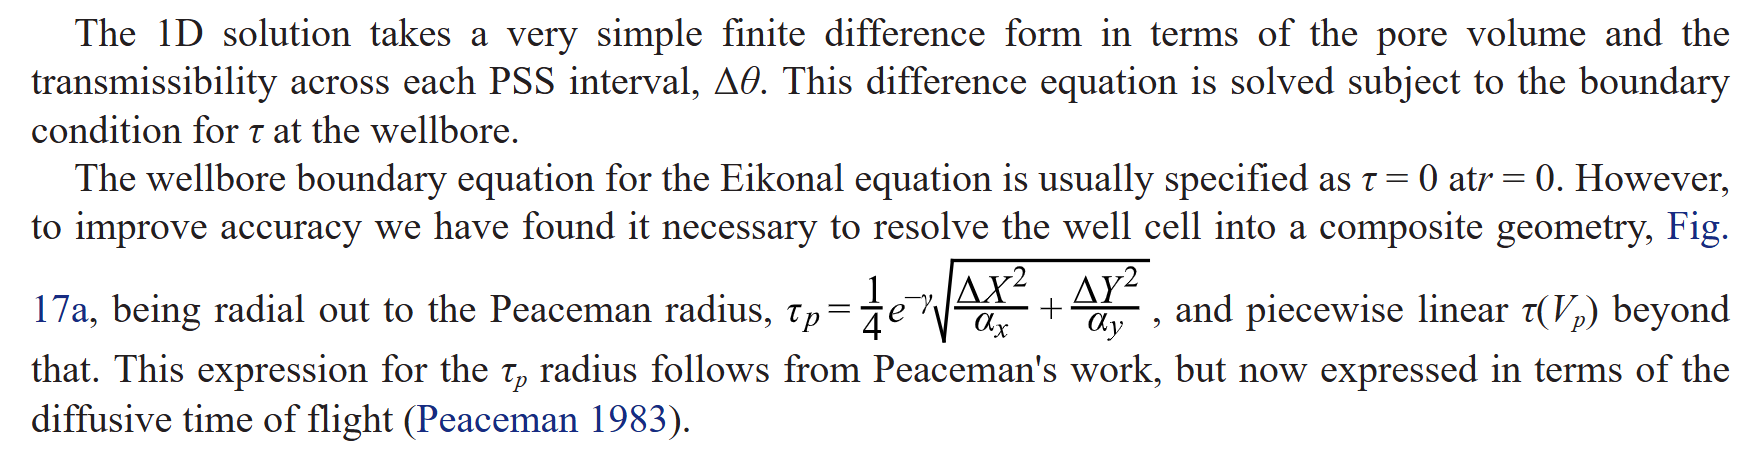

In [190]:
# Новая версия
def theta_to_tau_map(theta_discret, Vp, ct, T_plus, T_minus, lambda_rt0):
    theta_unique = np.sort(np.unique(theta_discret))
    print(f"PSS интервалы: {len(theta_unique)}")
    
    if len(theta_unique) < 2:
        raise ValueError("Нужно минимум 2 PSS интервала")
    
    delta_Vp = np.zeros(len(theta_unique))
    for i, theta_val in enumerate(theta_unique):
        mask = (theta_discret == theta_val)
        delta_Vp[i] = np.sum(Vp[mask])
    
    tau_intervals = np.zeros(len(theta_unique))
    tau_intervals[0] = 0
    for i in range(1, len(theta_unique)):
        tau_intervals[i] = tau_intervals[i-1] + np.sqrt(ct/lambda_rt0 * (1/T_minus[i] + 1/T_plus[i-1])*delta_Vp[i])
    
    tau_map = np.zeros(theta_discret.shape)
    for i, theta_val in enumerate(theta_unique):
        mask = (theta_discret == theta_val)
        tau_map[mask] = tau_intervals[i]
    return tau_map, theta_unique, tau_intervals

PSS интервалы: 14
tau_map shape: (20, 26)


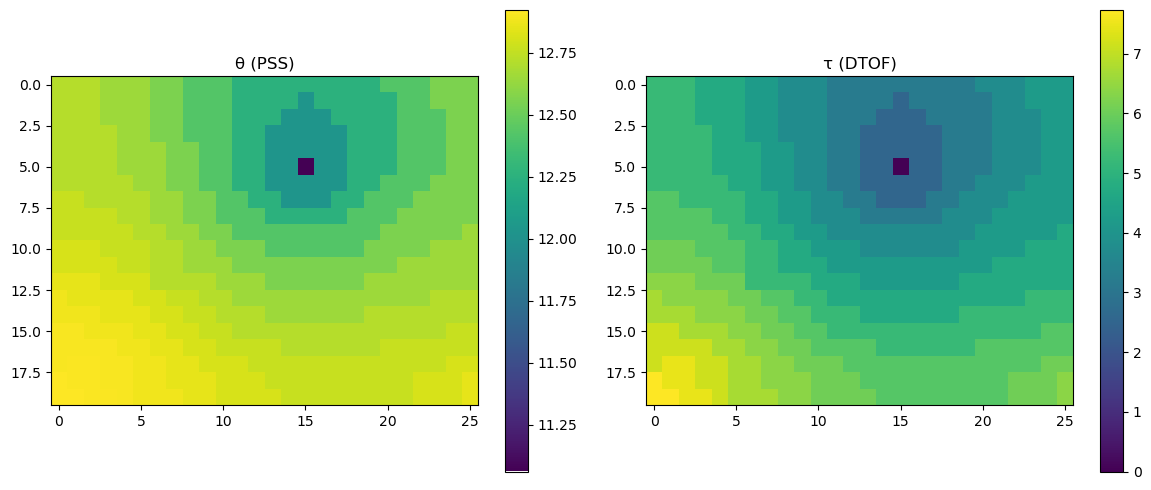

In [191]:
NY, NX = theta_discret_1.shape
well_i, well_j = Well_1[0], Well_1[1]

Vp = dx_1**2 * poros

tau_map_1, theta_int_1, tau_int_1 = theta_to_tau_map(theta_discret_1, Vp, ct, T_plus_1, T_minus_1, lam[0])

print(f"tau_map shape: {tau_map_1.shape}")
plt.figure(figsize=(12, 5))
plt.subplot(121); plt.imshow(theta_discret_1); plt.colorbar(); plt.title('θ (PSS)')
plt.subplot(122); plt.imshow(tau_map_1); plt.colorbar(); plt.title('τ (DTOF)')
plt.tight_layout()
plt.show()

PSS интервалы: 17
tau_map shape: (20, 26)


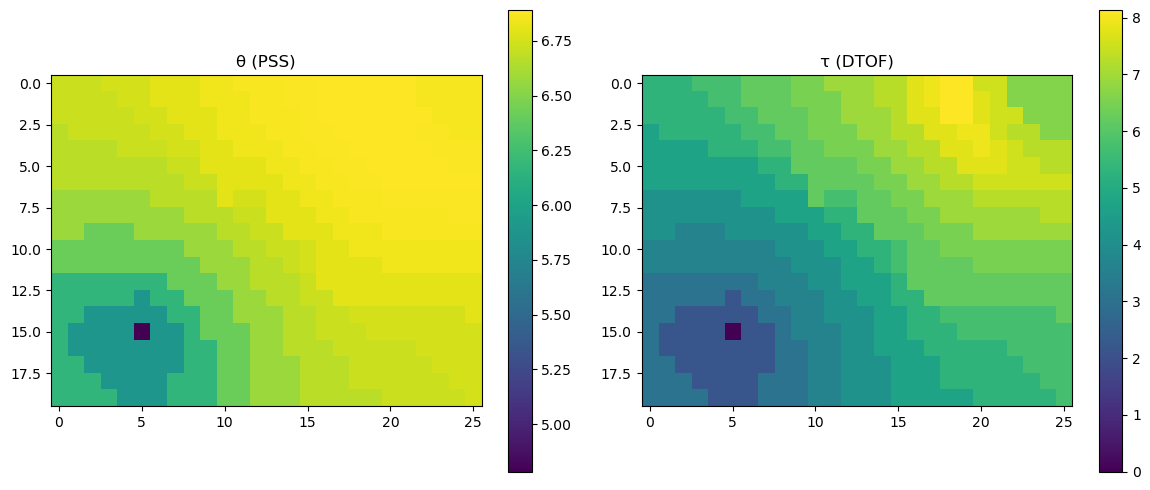

In [192]:
tau_map_2, theta_int_2, tau_int_2 = theta_to_tau_map(theta_discret_2, Vp, ct, T_plus_2, T_minus_2, lam[0])

print(f"tau_map shape: {tau_map_2.shape}")
plt.figure(figsize=(12, 5))
plt.subplot(121); plt.imshow(theta_discret_2); plt.colorbar(); plt.title('θ (PSS)')
plt.subplot(122); plt.imshow(tau_map_2); plt.colorbar(); plt.title('τ (DTOF)')
plt.tight_layout()
plt.show()

In [193]:
q_f = q_f_1

q_inside = np.zeros_like(q_f)
for i in range(len(q_f)):
    for j in range(len(q_f)):
        if j < i+1:
            q_inside[i] += q_f[j]
q_inside[len(q_f)-1] == np.sum(q_f)

q_inside_1 =  q_inside
q_f = q_f_2

q_inside = np.zeros_like(q_f)
for i in range(len(q_f)):
    for j in range(len(q_f)):
        if j < i+1:
            q_inside[i] += q_f[j]
q_inside[len(q_f)-1] == np.sum(q_f)

q_inside_2 =  q_inside

In [194]:
q_f = q_f_1
q_inside = q_inside_1

q_dmnless = np.zeros_like(q_f)
for i in range(len(q_f)):
    q_dmnless[i] = (np.sum(q_f) - q_inside[i])/(np.sum(q_f)-q_f[0])
q_dmnless

q_dmnless_1 = q_dmnless

q_f = q_f_2
q_inside = q_inside_2

q_dmnless = np.zeros_like(q_f)
for i in range(len(q_f)):
    q_dmnless[i] = (np.sum(q_f) - q_inside[i])/(np.sum(q_f)-q_f[0])
q_dmnless

q_dmnless_2 = q_dmnless

In [195]:
q_t_1 = np.sum(q_f_1)
q_t_2 = np.sum(q_f_2)


In [196]:
q_f = q_f_1
q_dmnless = q_dmnless_1
T_minus = T_minus_1
T_plus = T_plus_1
q_t = q_t_1

pss_drop_theta = np.zeros(len(q_f))

for i in range (0,len(q_f)):
    mult = 0
    for j in range (0,i):
        mult += (q_dmnless[j-1]/T_minus[j] + q_dmnless[j]/T_plus[j])
    pss_drop_theta[i] = mult * mu * q_t

pss_drop_theta_1 = pss_drop_theta

q_f = q_f_2
q_dmnless = q_dmnless_2
T_minus = T_minus_2
T_plus = T_plus_2
q_t = q_t_2

pss_drop_theta = np.zeros(len(q_f))

for i in range (0,len(q_f)):
    mult = 0
    for j in range (0,i):
        mult += (q_dmnless[j-1]/T_minus[j] + q_dmnless[j]/T_plus[j])
    pss_drop_theta[i] = mult * mu * q_t

pss_drop_theta_2 = pss_drop_theta


# По шагам

## $R(\tau)$

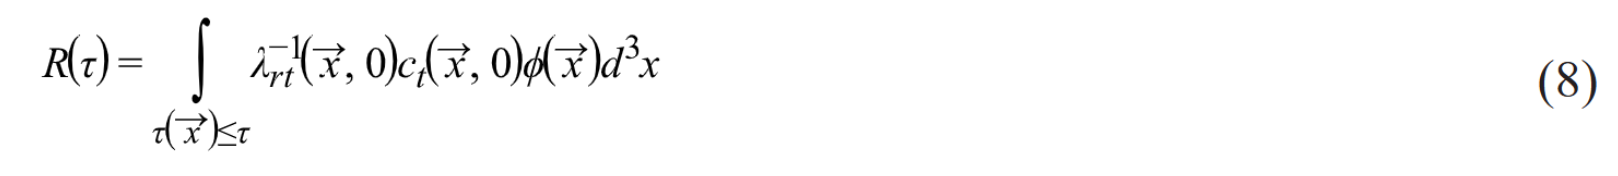

In [197]:
def compute_R (tau_map, tau_int, lam, ct, poros, dx):
    R = np.zeros(len(tau_int))
    for i, tau in enumerate(tau_int):
        mask = (tau_map <= tau)
        phi = np.sum(poros[mask])
        R[i] = ct * phi * dx * dx /lam
    return R

In [198]:
R_1 = compute_R (tau_map_1, tau_int_1, lam[0], ct, poros, dx_1)
R_2 = compute_R (tau_map_2, tau_int_2, lam[0], ct, poros, dx_1)

## $w_r(\tau)$

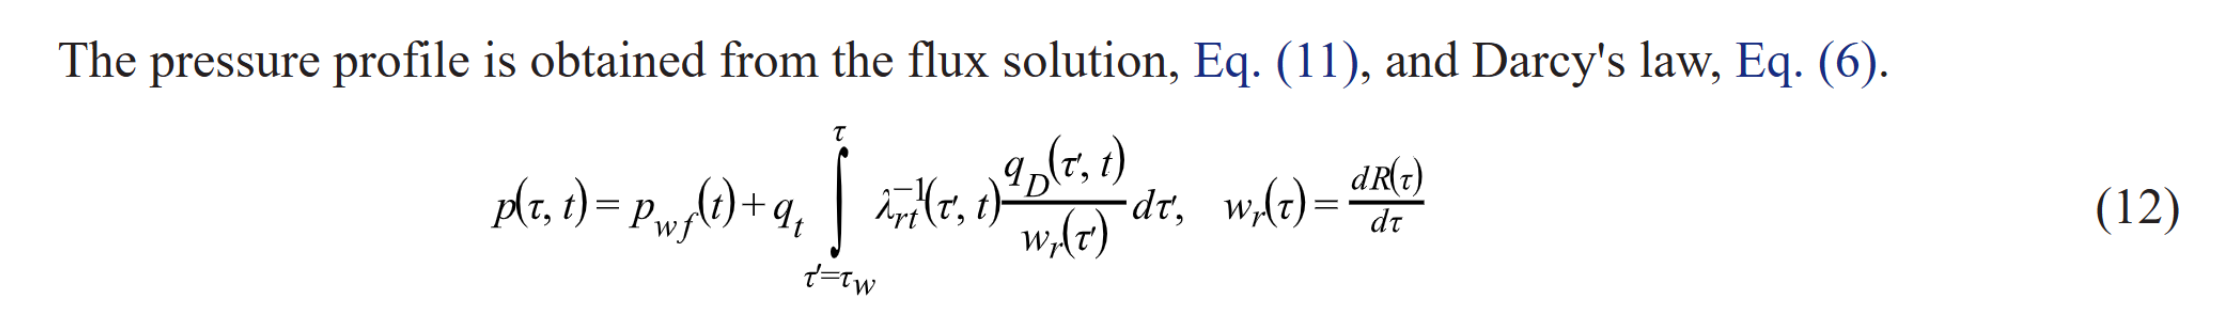

In [199]:
def compute_w_r(R, tau_int):
    '''
    w_r(\tau) - derivative of cumulative reservoir resistivity with respect to \tau
    Вычисляется как конечно-разностная произвадная R по tau. Для сохранения размерностей первые два значения равны.
    Для w_r[0] используется правая разностная производная, далее - левая.

    delta_tau добавил позже, так удобнее было
    '''
    w_r = np.zeros(len(tau_int))
    delta_tau = np.zeros(len(tau_int))

    w_r[0] = (R[1]-R[0])/(tau_int[1]-tau_int[0])
    delta_tau[0] = tau_int[1] - tau_int[0]

    for i in range(1,len(tau_int)):
        w_r[i] = (R[i]-R[i-1])/(tau_int[i]-tau_int[i-1])
        delta_tau[i] = tau_int[i] - tau_int[i-1]
    return w_r, delta_tau

In [200]:
w_r_1, delta_tau_1 = compute_w_r(R_1, tau_int_1)
w_r_2, delta_tau_2 = compute_w_r(R_2, tau_int_2)

## $J^{-1}_{t,j}$

Здесь j - номер скважины (у нас $j=1,2$)

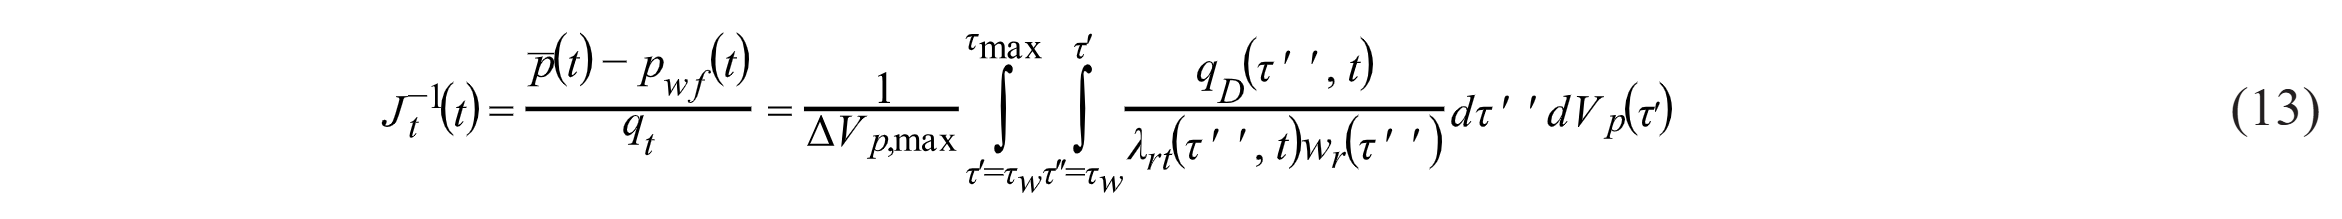

Использовал формулу: $$ \frac{1}{\Delta V_{p,max}} \sum_{\tau'=\tau_w}^{\tau_{max}}{\sum_{\tau''=\tau_w}^{\tau'}\frac{q_D(\tau'',t)}{\lambda_{rt}w_r(\tau'')}\Delta \tau'' \Delta V_p(\tau')} $$

In [201]:
def compute_J(Vp, tau_map ,tau_int, q_dmnless, lam, w_r, delta_tau):
    delta_Vp = np.zeros(len(tau_int))
    for i, tau_val in enumerate(tau_int):
        mask = (tau_map == tau_val)
        delta_Vp[i] = np.sum(Vp[mask])
    result = 0

    for i in range(0,len(tau_int)):
        sum = 0
        for j in range(0,i+1):
            sum += (q_dmnless[j]/(lam*w_r[j])) * delta_tau[j]
        result +=  sum * delta_Vp[i]
    result = result / np.sum(Vp)
    #result = result / delta_Vp.max()
    return result

In [202]:
J_1 = compute_J(Vp,tau_map_1, tau_int_1, q_dmnless_1, lam[0] ,w_r_1, delta_tau_1)
J_2 = compute_J(Vp,tau_map_2, tau_int_2, q_dmnless_2, lam[0] ,w_r_2, delta_tau_2)

## M

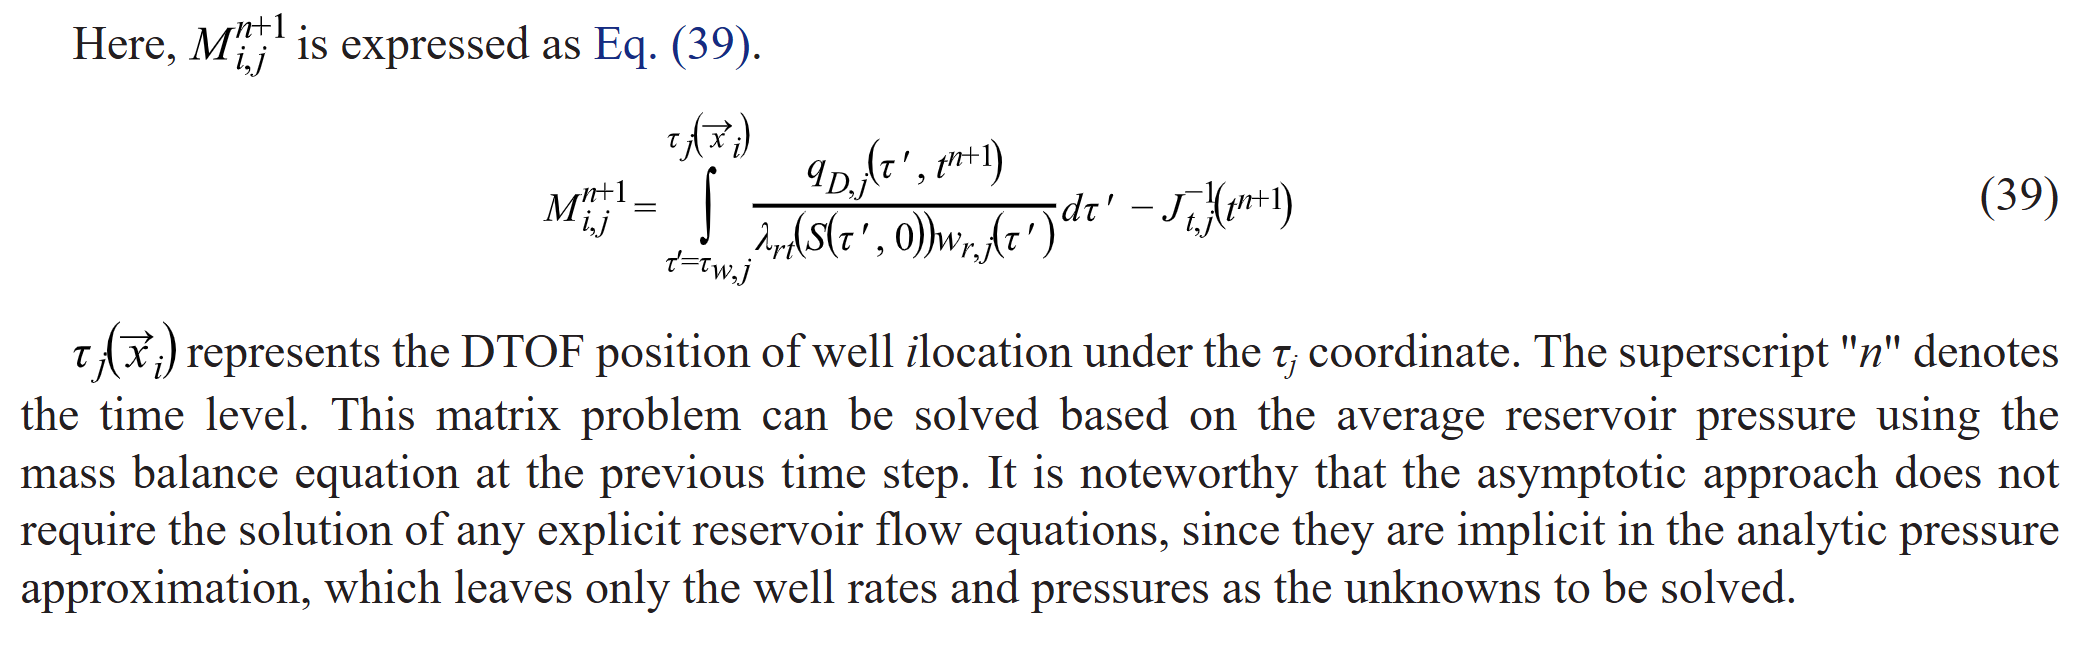

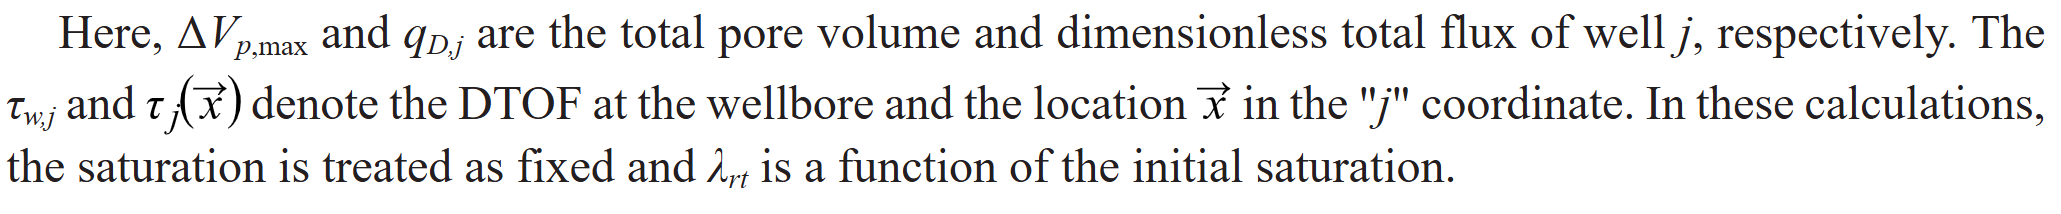

In [203]:
def compute_M(tau_int, tau_map, q_dmnless, Wells_coords, lam, w_r, delta_tau, J):
    result = 0
    tau_value_in_well = tau_map[Wells_coords[0], Wells_coords[1]]
    for i, tau in enumerate (tau_int):
        result += q_dmnless[i]/(lam*w_r[i])* delta_tau[i]
        if tau == tau_value_in_well:
            break
    print (result)
    result -= J
    return result

In [204]:
M_11 = -J_1
M_12 = compute_M(tau_int_1, tau_map_1, q_dmnless_1, Well_2, lam[0], w_r_1, delta_tau_1, J_1)
M_22 = -J_2
M_21 = compute_M(tau_int_2, tau_map_2, q_dmnless_2, Well_1, lam[0], w_r_2, delta_tau_2, J_2)

2.1521568290887445
1.5717938983541004


# Решение системы

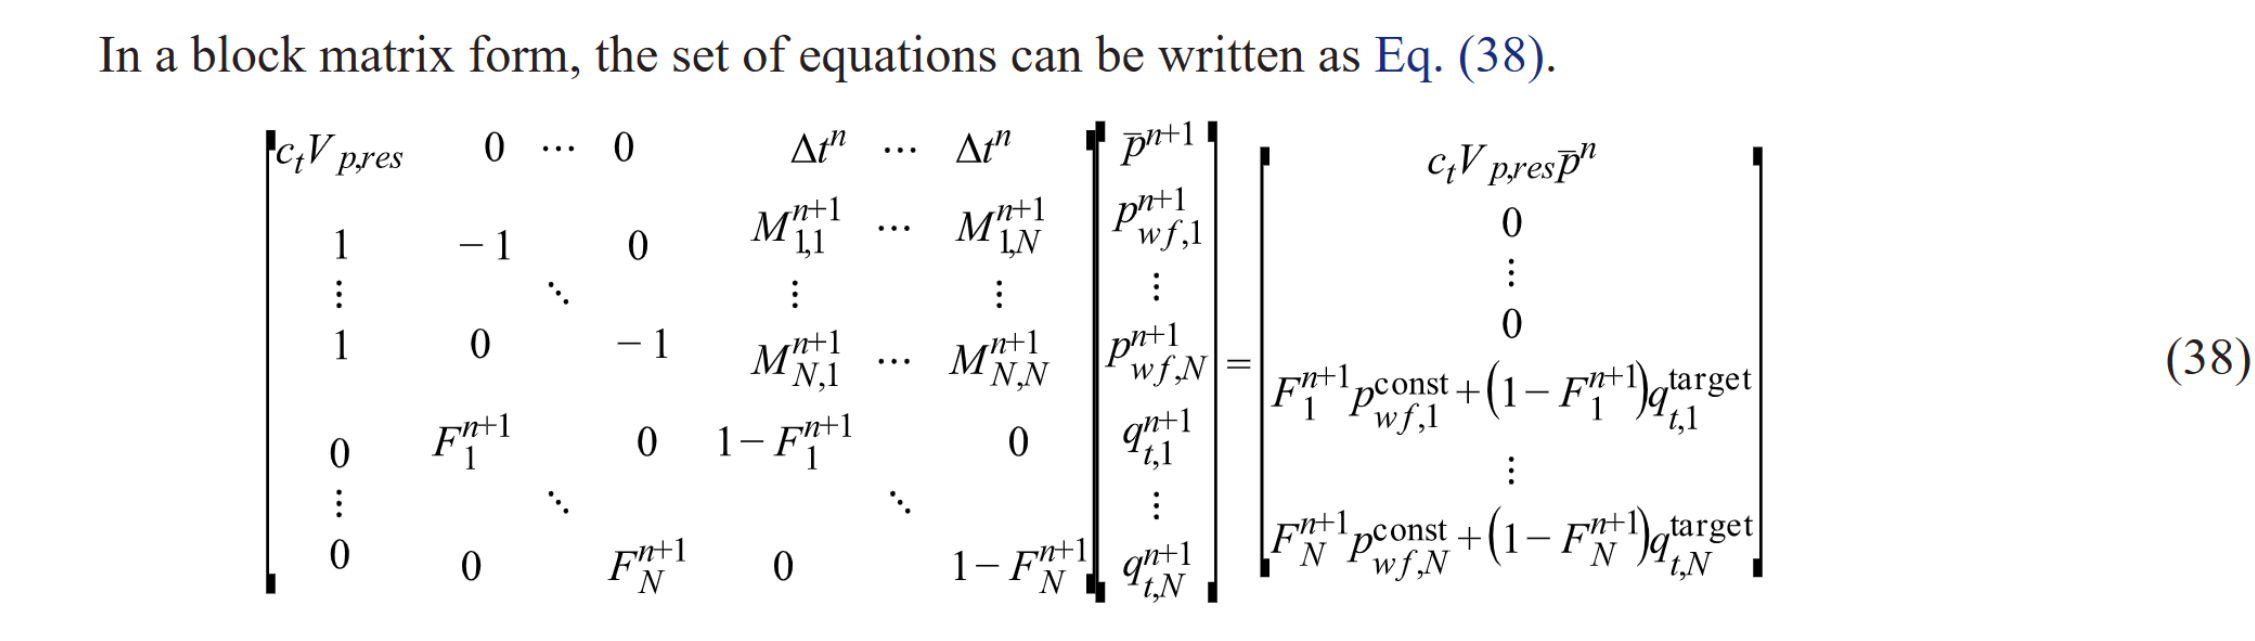

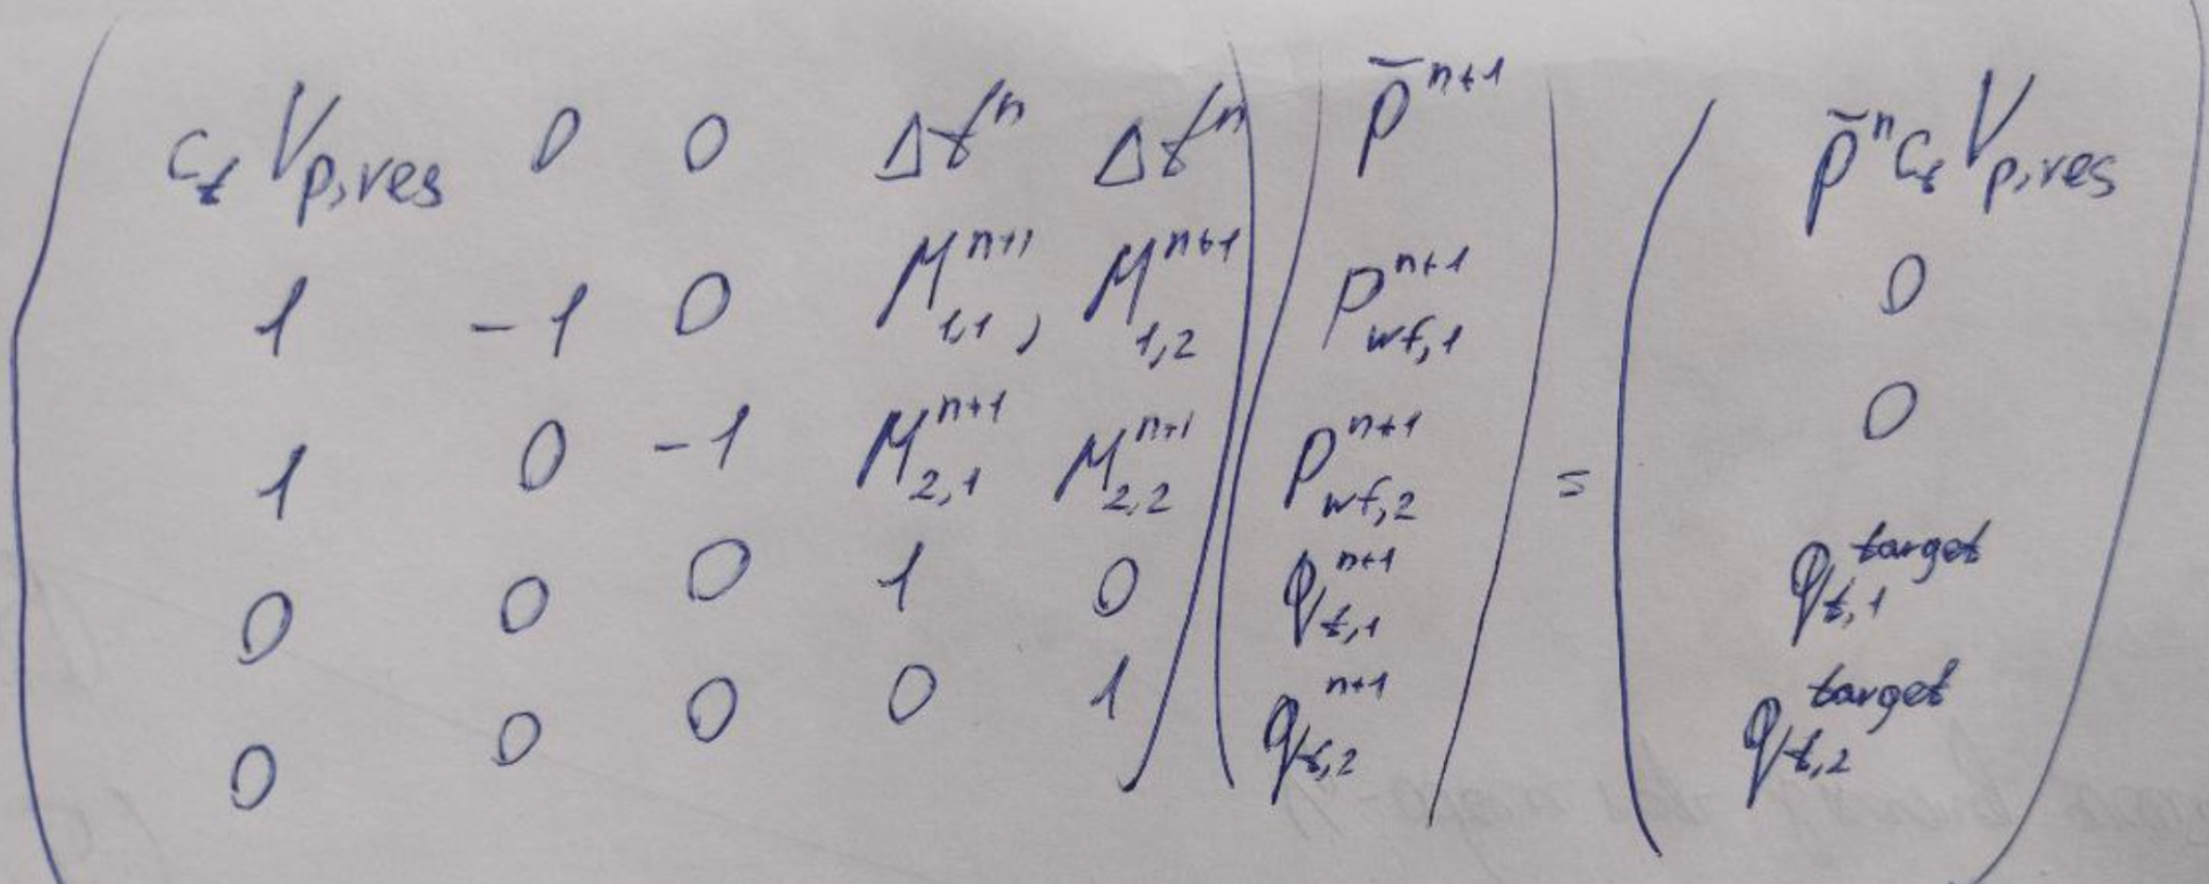

In [205]:
Q_t = 2 * qw * time

In [206]:
def const_matrix(c_t,V_res,dt,M_11, M_12, M_21, M_22):
    M=np.zeros((5,5), dtype=float)
    M[0][0] = c_t * V_res
    M[0][3] = dt
    M[0][4] = dt
    M[1][0] = 1
    M[1][1] = -1
    M[1][3] = M_11
    M[1][4] = M_22
    M[2][0] = 1
    M[2][2] = -1
    M[2][3] = M_21
    M[2][4] = M_22
    M[3][3] = 1
    M[4][4] = 1
    return M

matrix = const_matrix(ct,V_res, dt, M_11, M_12, M_21, M_22)


y = np.zeros(5)
y[0] = PInit * ct * V_res
y[3] = Q_t
y[4] = Q_t


# Решение системы
x = np.linalg.solve(matrix, y)


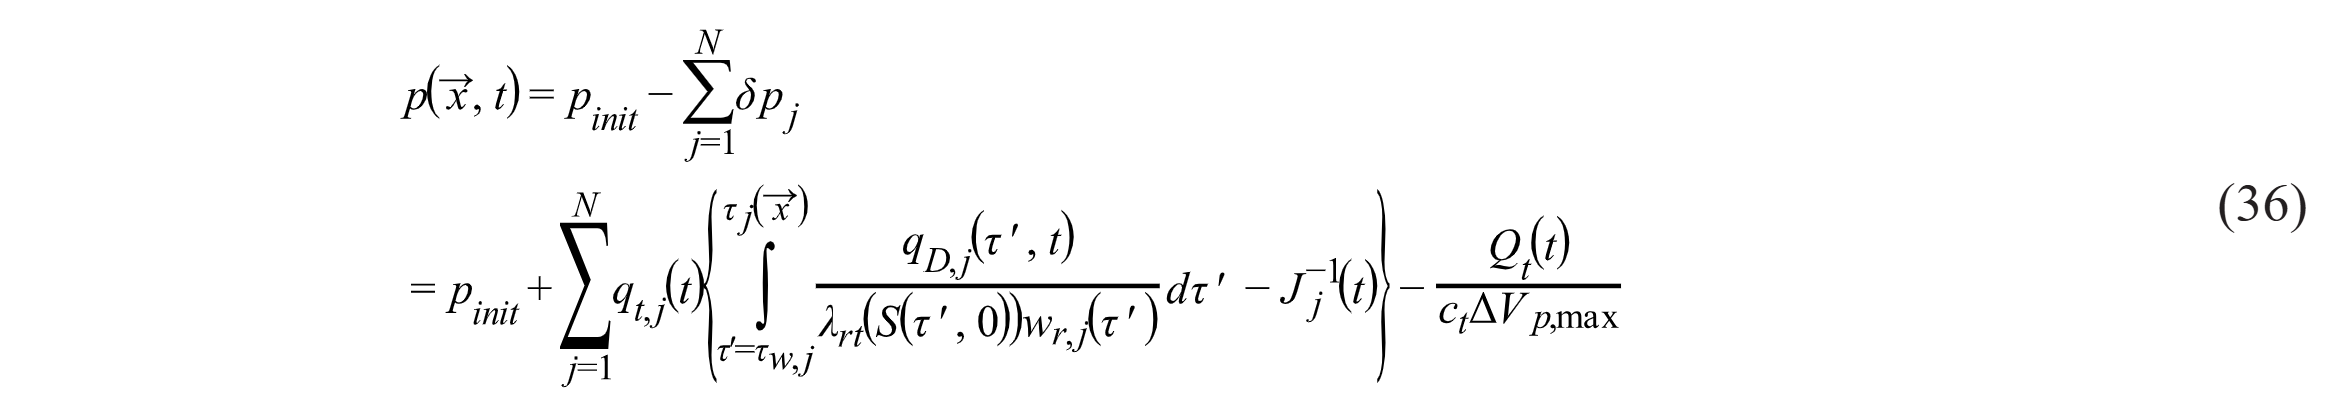

In [208]:
V_p_max = np.sum(V)

In [ ]:
p_x = np.zeros((poros.shape[0], poros.shape[1]))
for i in range (0, poros.shape[0]):
    for j in range (0, poros.shape[1]):
        sl_1 = 0
        tau_value_in_well = tau_map_1[i,j]
        for k, tau in enumerate (tau_int_1):
            sl_1 += q_dmnless_1[k]/(lam[0]*w_r_1[k])* delta_tau_1[k]
            if tau == tau_value_in_well:
                break
        sl_1 -= J_1
        sl_1 = sl_1 * x[3]


        sl_2 = 0
        tau_value_in_well = tau_map_2[i,j]
        for k, tau in enumerate (tau_int_2):
            sl_2 += q_dmnless_2[k]/(lam[0]*w_r_2[k])* delta_tau_2[k]
            if tau == tau_value_in_well:
                break
        sl_2 -= J_2
        sl_2 = sl_2 * x[4]

        p_x[i,j] = PInit + sl_1 + sl_2 - Q_t/(ct*V_p_max)

# Результаты

In [210]:
print(f'p_x min = {p_x.min()}')
print(f'p_x max = {p_x.max()}')

p_x min = -6.4180517275663185
p_x max = 208.26124792866585


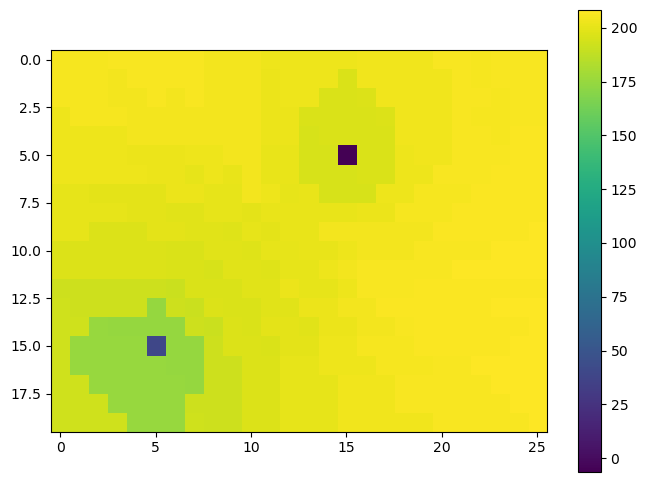

In [211]:
plt.figure(figsize=(8, 6))
plt.imshow(
    p_x
)
plt.colorbar()

plt.show()

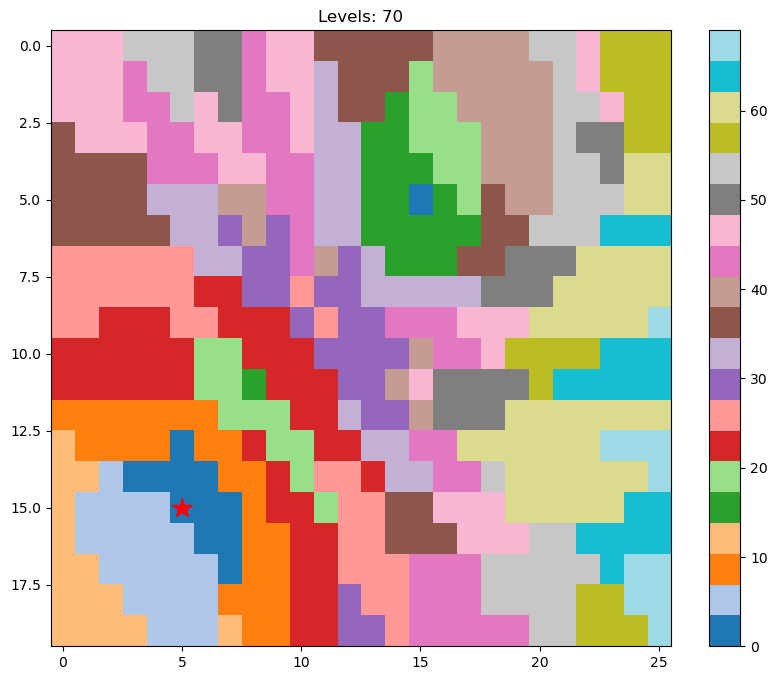

In [139]:
theta_discret = p_x
well_i = Well_2[0]
well_j = Well_2[1]

unique_levels = np.unique(theta_discret)
level_map = np.zeros_like(theta_discret, dtype=int)
for idx, level in enumerate(unique_levels):
    level_map[theta_discret == level] = idx

plt.figure(figsize=(10, 8))
plt.imshow(level_map, cmap='tab20', aspect='auto', interpolation='none')
plt.plot(well_j, well_i, 'r*', markersize=15)
plt.colorbar()
plt.title(f'Levels: {len(unique_levels)}')
plt.show()